# Phase 4: Exploratory Data Analysis

## Objectives

This phase covers:

1. Conduct comprehensive univariate analysis
2. Perform bivariate analysis to understand feature relationships
3. Analyze the target variable distribution
4. Identify key patterns and insights in the data
5. Validate assumptions and feature engineering decisions
6. Create visualizations that tell the story of house prices
7. Prepare final recommendations for modeling

## Notes

EDA is both an art and a science. Look for patterns, anomalies, and insights that will guide modeling decisions.

---
## Step 1: Import Libraries and Load Data

In [155]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

pd.set_option('display.max_columns', None)

print("Pandas display options set successfully.")

Pandas display options set successfully.


In [156]:
df_fe = pd.read_csv('../data/train/train_feature_engineered.csv')
df_original = pd.read_csv('../data/train/train_cleaned.csv')
y = df_original[['SalePrice']]
print(f"Feature-engineered dataset: {df_fe.shape}")
print(f"Original dataset: {df_original.shape}")
print(f"Target variable: {y.shape}")

Feature-engineered dataset: (1184, 157)
Original dataset: (1184, 75)
Target variable: (1184, 1)


### Step 2.1: Statistical Summary of Target Variable

In [157]:
saleprice_stats = {
    'Count': y['SalePrice'].count(),
    'Mean': y['SalePrice'].mean(),
    'Median': y['SalePrice'].median(),
    'Standard Deviation': y['SalePrice'].std(),
    'Minimum': y['SalePrice'].min(),
    'Maximum': y['SalePrice'].max(),
    'Range': y['SalePrice'].max() - y['SalePrice'].min(),
    'Q1 (25%)': y['SalePrice'].quantile(0.25),
    'Q2 (50%)': y['SalePrice'].quantile(0.50),
    'Q3 (75%)': y['SalePrice'].quantile(0.75),
    'Skewness': stats.skew(y['SalePrice']),
    'Kurtosis': stats.kurtosis(y['SalePrice'])
}
print("Comprehensive Statistics for SalePrice:")
for stat, value in saleprice_stats.items():
    print(f"{stat}: {value:,.2f}")


Comprehensive Statistics for SalePrice:
Count: 1,184.00
Mean: 172,293.48
Median: 159,697.50
Standard Deviation: 62,389.06
Minimum: 34,900.00
Maximum: 451,950.00
Range: 417,050.00
Q1 (25%): 130,000.00
Q2 (50%): 159,697.50
Q3 (75%): 201,975.00
Skewness: 1.11
Kurtosis: 1.65


### Step 2.2: Visualize Target Distribution

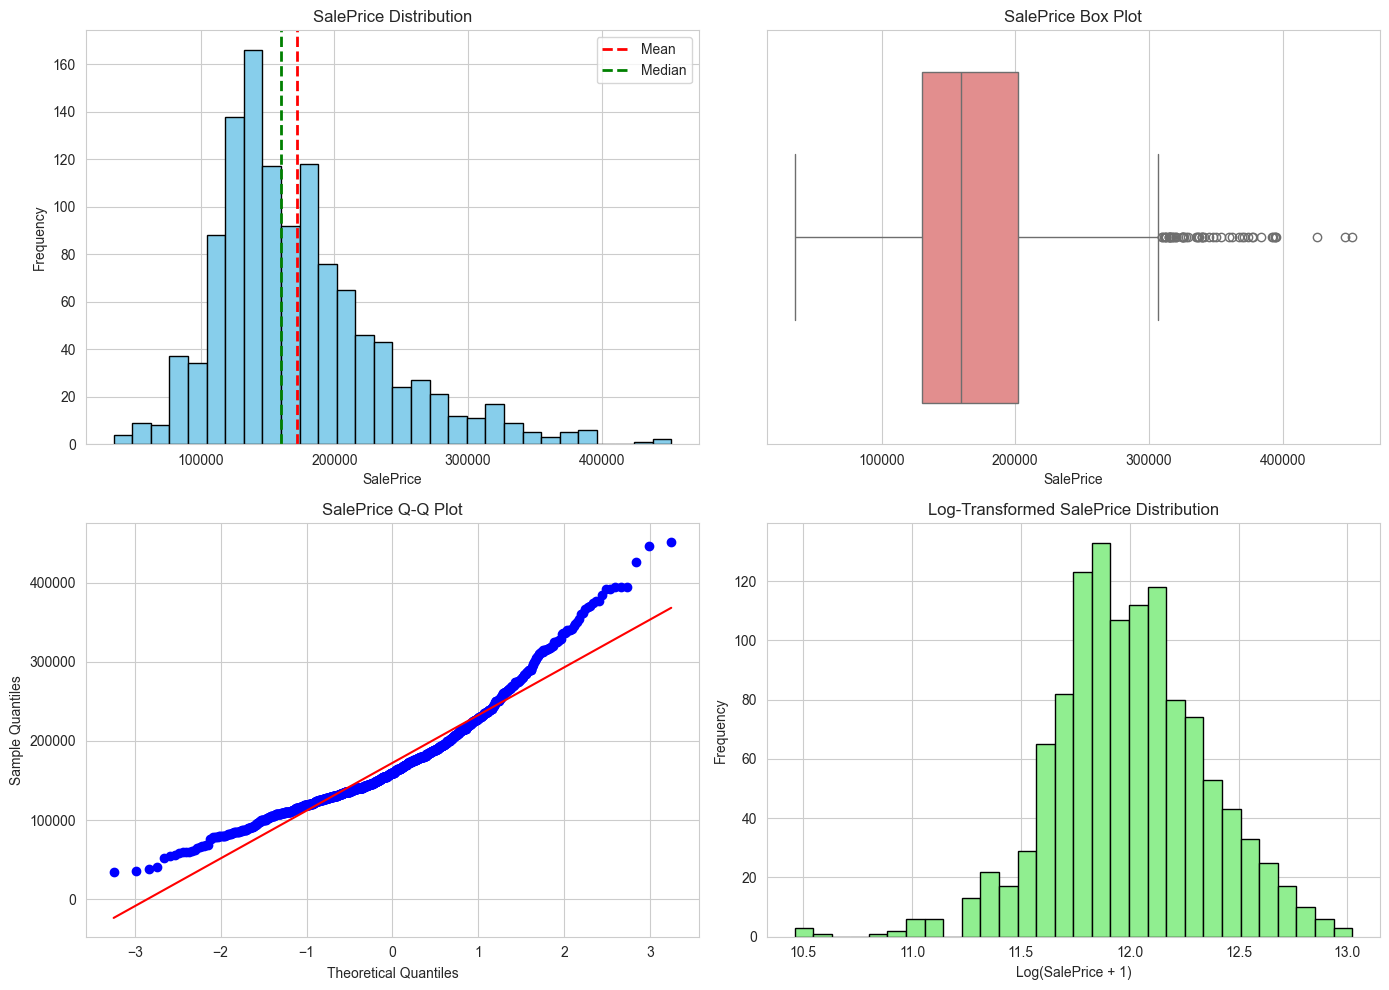

In [158]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(y['SalePrice'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].axvline(y['SalePrice'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
axes[0, 0].axvline(y['SalePrice'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
axes[0, 0].set_title('SalePrice Distribution')
axes[0, 0].set_xlabel('SalePrice')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
sns.boxplot(x=y['SalePrice'], ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('SalePrice Box Plot')
stats.probplot(y['SalePrice'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('SalePrice Q-Q Plot')
axes[1, 0].set_xlabel('Theoretical Quantiles')
axes[1, 0].set_ylabel('Sample Quantiles')
axes[1, 1].hist(np.log1p(y['SalePrice']), bins=30, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Log-Transformed SalePrice Distribution')
axes[1, 1].set_xlabel('Log(SalePrice + 1)')
axes[1, 1].set_ylabel('Frequency')  
plt.tight_layout()
plt.show()

### Your Analysis:

Observations on the target variable:
- Is the distribution normal or skewed? 
- Are there outliers?
- What price range do most houses fall into?
- Does log transformation improve normality?

---
## Step 3: Univariate Analysis - Numerical Features

Individual numerical feature review.

In [159]:
numerical_features = df_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Id' in numerical_features:
    numerical_features.remove('Id')
if 'SalePrice' in numerical_features:
    numerical_features.remove('SalePrice')
print(f"Total numerical features being analyzed: {len(numerical_features)}")

Total numerical features being analyzed: 71


### Step 3.1: Distribution Analysis of Key Numerical Features

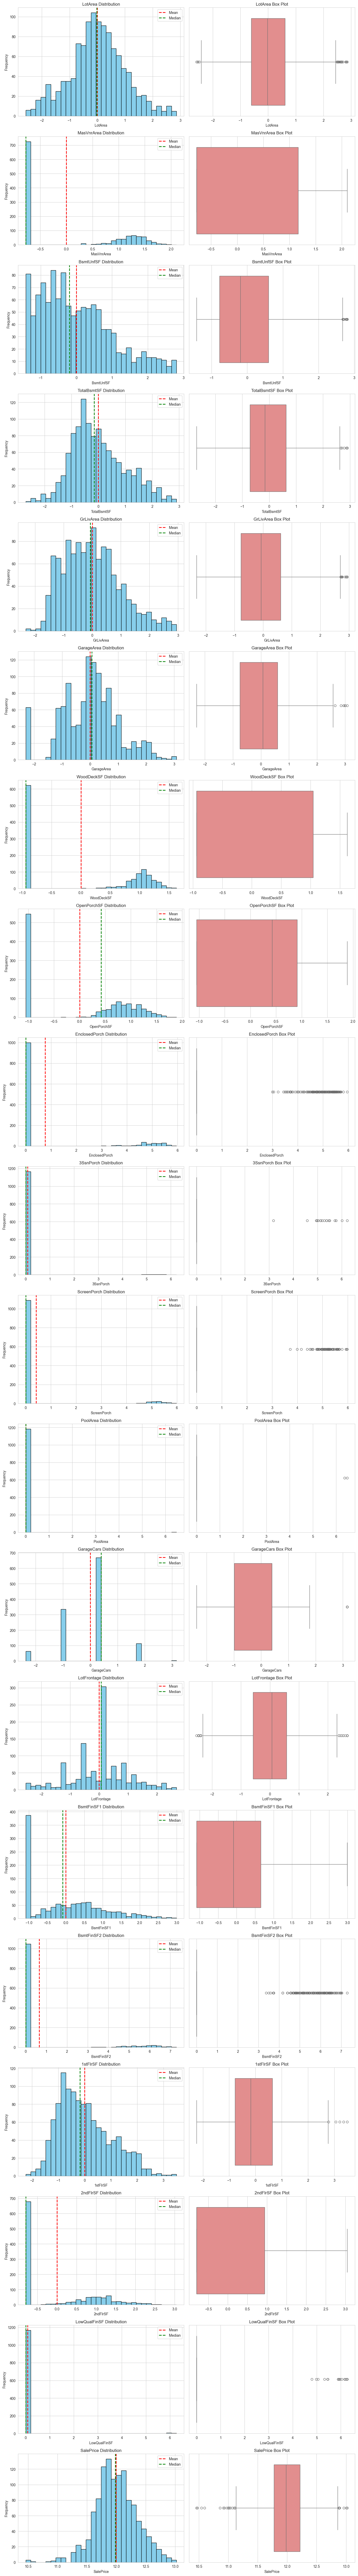

In [160]:
key_features = ['LotArea', 'MasVnrArea', 'BsmtUnfSF', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
'3SsnPorch', 'ScreenPorch', 'PoolArea', 'GarageCars','LotFrontage','BsmtFinSF1','BsmtFinSF2','1stFlrSF', '2ndFlrSF','LowQualFinSF','SalePrice']
fig, axes = plt.subplots(len(key_features), 2, figsize=(14, 5 * len(key_features)))
for i, feature in enumerate(key_features):
    if feature in df_fe.columns:
        axes[i, 0].hist(df_fe[feature], bins=30, color='skyblue', edgecolor='black')
        axes[i, 0].axvline(df_fe[feature].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
        axes[i, 0].axvline(df_fe[feature].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
        axes[i, 0].set_title(f'{feature} Distribution')
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel('Frequency')
        axes[i, 0].legend()
        sns.boxplot(x=df_fe[feature], ax=axes[i, 1], color='lightcoral')
        axes[i, 1].set_title(f'{feature} Box Plot')
plt.tight_layout()
plt.show()

---
## Step 4: Univariate Analysis - Categorical Features

Categorical distribution review.

In [161]:
categorical_features = df_original.select_dtypes(include=['object']).columns.tolist()
print(f"Total categorical features: {len(categorical_features)}")
for feature in categorical_features:
    unique_count = df_original[feature].nunique()
    print(f"{feature}: {unique_count} unique values")

Total categorical features: 37
MSZoning: 5 unique values
Street: 2 unique values
LotShape: 4 unique values
LandContour: 4 unique values
Utilities: 2 unique values
LotConfig: 5 unique values
LandSlope: 3 unique values
Neighborhood: 23 unique values
Condition1: 9 unique values
Condition2: 4 unique values
BldgType: 5 unique values
HouseStyle: 8 unique values
RoofStyle: 5 unique values
RoofMatl: 5 unique values
Exterior1st: 14 unique values
Exterior2nd: 16 unique values
ExterQual: 4 unique values
ExterCond: 5 unique values
Foundation: 5 unique values
BsmtQual: 4 unique values
BsmtCond: 4 unique values
BsmtFinType1: 6 unique values
BsmtFinType2: 6 unique values
Heating: 4 unique values
HeatingQC: 5 unique values
CentralAir: 2 unique values
Electrical: 5 unique values
KitchenQual: 4 unique values
Functional: 6 unique values
FireplaceQu: 6 unique values
GarageType: 7 unique values
GarageFinish: 4 unique values
GarageQual: 6 unique values
GarageCond: 6 unique values
PavedDrive: 3 unique values

### Step 4.1: Visualize Key Categorical Features

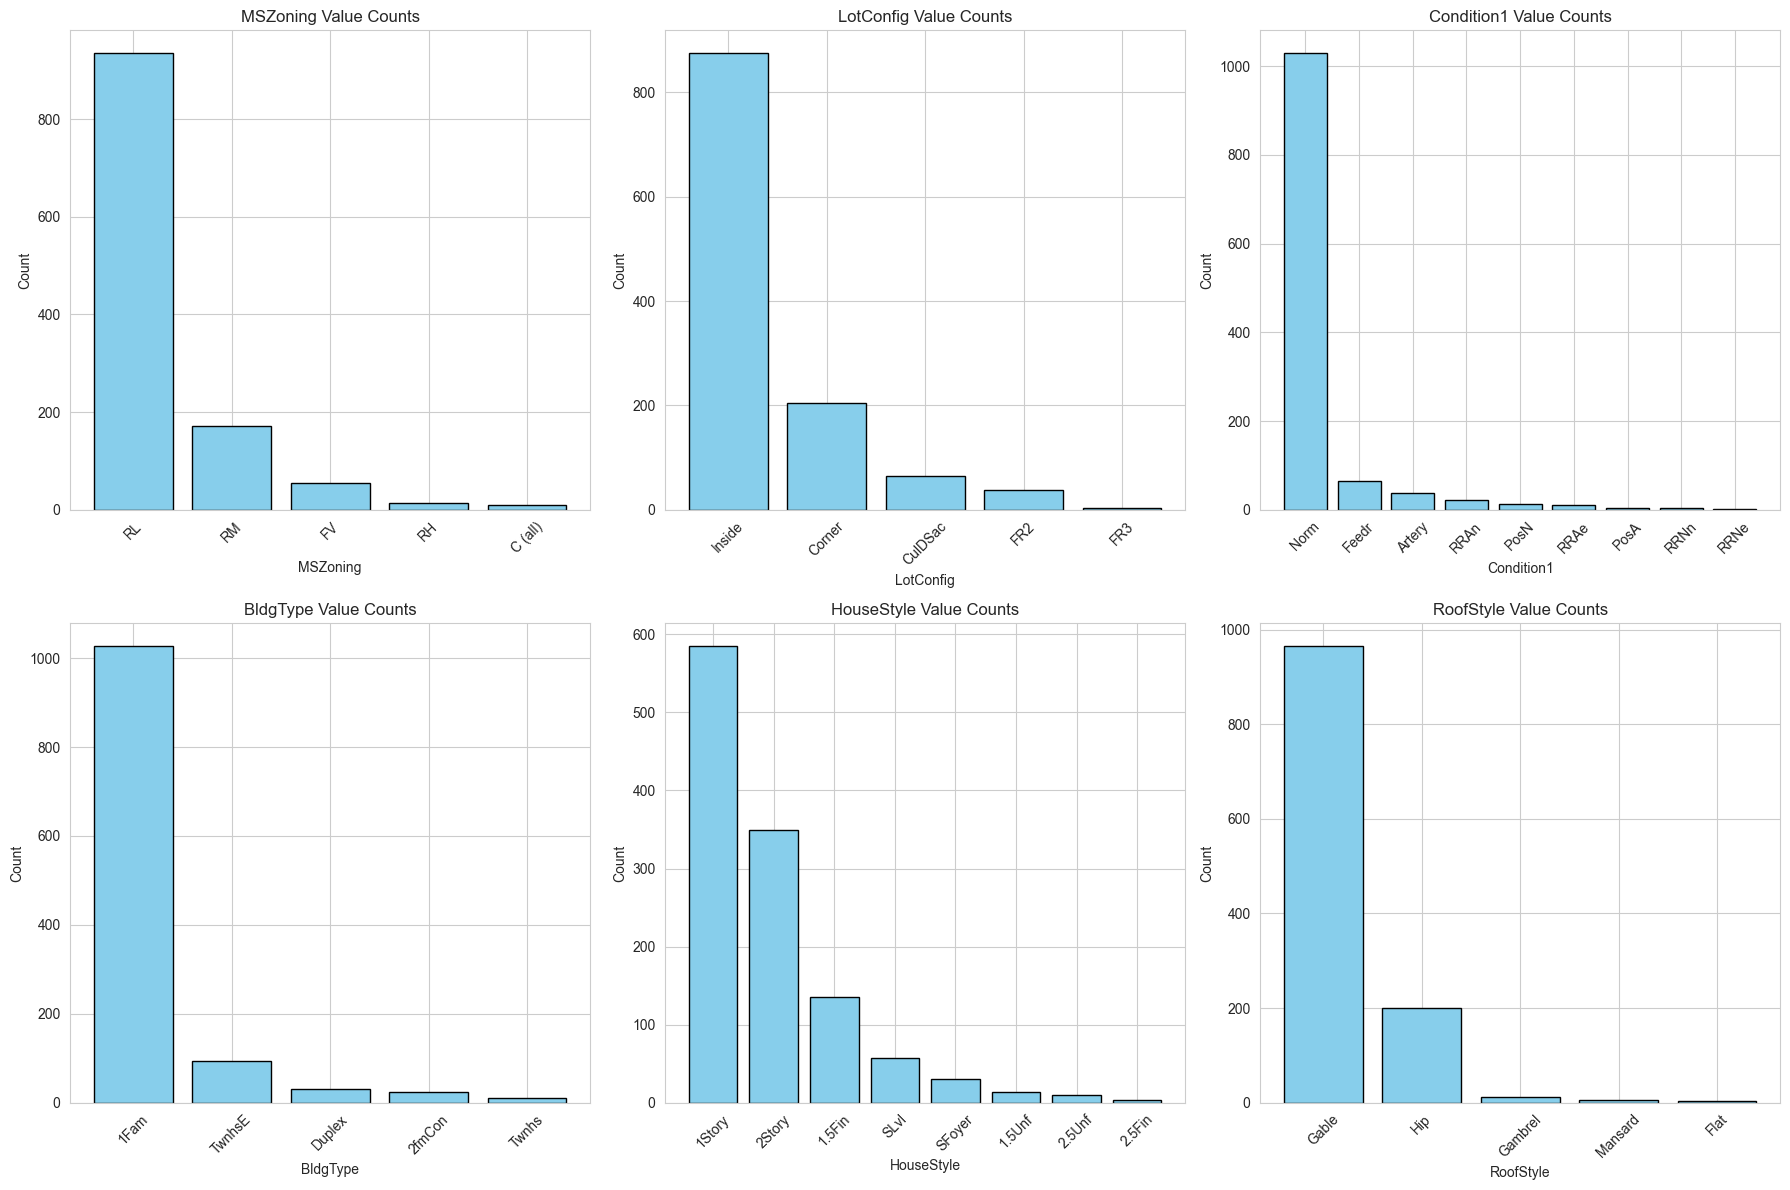

In [162]:
key_categorical_features = [col for col in categorical_features if (df_original[col].nunique() >= 5) & (df_original[col].nunique() <= 15)]
key_categorical_features = key_categorical_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, feature in enumerate(key_categorical_features):
    value_counts = df_original[feature].value_counts()
    axes[i // 3, i % 3].bar(value_counts.index, value_counts.values, color='skyblue', edgecolor='black')
    axes[i // 3, i % 3].set_title(f'{feature} Value Counts')
    axes[i // 3, i % 3].set_xlabel(feature)
    axes[i // 3, i % 3].set_ylabel('Count')
    axes[i // 3, i % 3].tick_params(axis='x', rotation=45)
for j in range(i + 1, 6):
    axes[j // 3, j % 3].axis('off')
plt.tight_layout()
plt.show()

---
## Step 5: Bivariate Analysis - Numerical vs Target

Numerical feature relationships vs SalePrice.

### Step 5.1: Correlation Analysis

In [163]:
num_cols = df_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_matrix = df_fe[num_cols].corr()
saleprice_correlations = correlation_matrix['SalePrice'].sort_values(ascending=False)
print("Top 15 features most correlated with SalePrice:")
print(saleprice_correlations.head(15))


Top 15 features most correlated with SalePrice:
SalePrice         1.000000
OverallQual       0.805782
TotalSF           0.777557
GrLivArea         0.678242
TotalBathrooms    0.671448
GarageCars        0.669956
ExterQual         0.667913
KitchenQual       0.655344
BsmtQual          0.653725
YearBuilt         0.652743
GarageArea        0.638093
GarageFinish      0.605766
FullBath          0.605258
YearRemodAdd      0.578484
TotalBsmtSF       0.563907
Name: SalePrice, dtype: float64


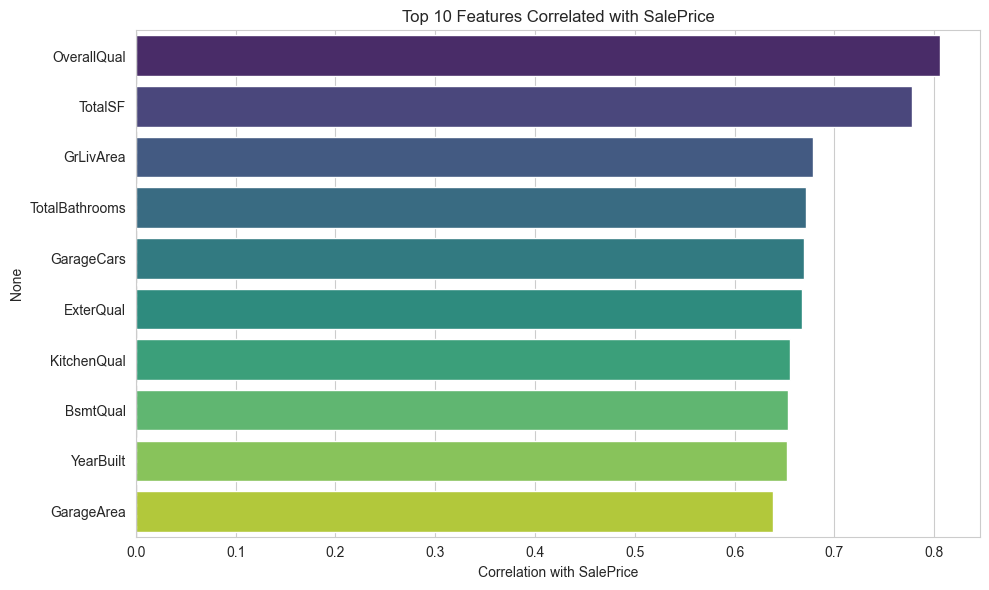

In [164]:
top_features = saleprice_correlations.drop('SalePrice').head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.xlabel('Correlation with SalePrice')
plt.title('Top 10 Features Correlated with SalePrice')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

### Step 5.2: Scatter Plots of Top Features vs SalePrice

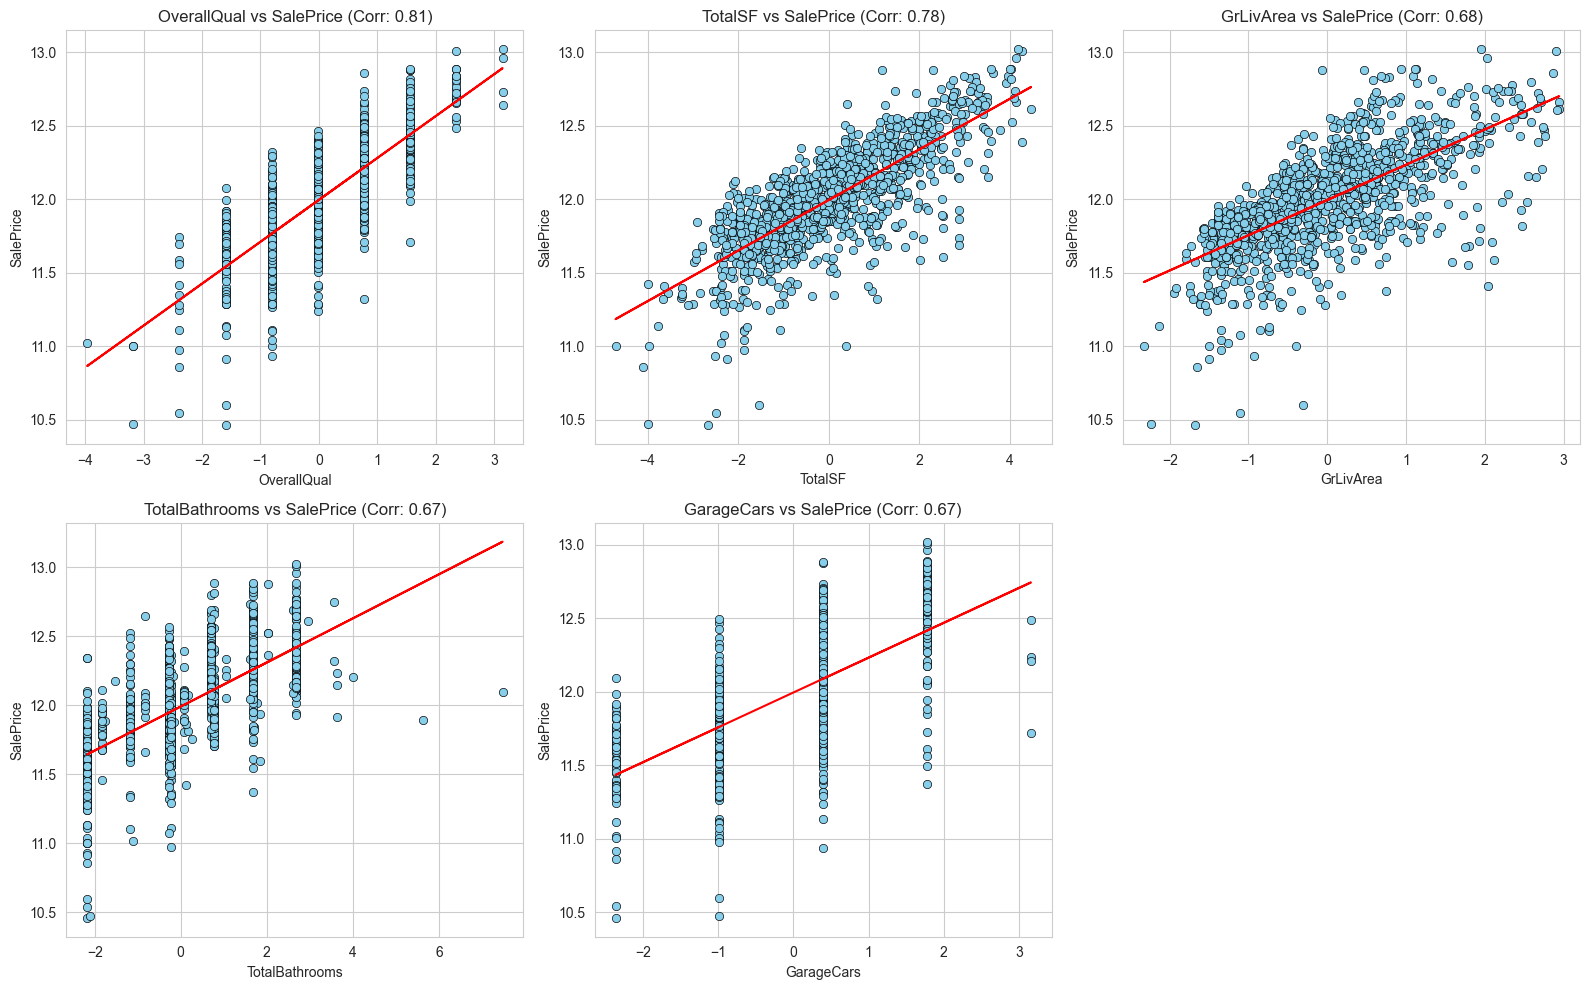

In [165]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, feature in enumerate(top_features.head(5).index):
    sns.scatterplot(x=df_fe[feature], y=df_fe['SalePrice'], ax=axes[i // 3, i % 3], color='skyblue', edgecolor='black')
    z = np.polyfit(df_fe[feature], df_fe['SalePrice'], 1)
    p = np.poly1d(z)
    axes[i // 3, i % 3].plot(df_fe[feature], p(df_fe[feature]), color='red')
    axes[i // 3, i % 3].set_title(f'{feature} vs SalePrice (Corr: {saleprice_correlations[feature]:.2f})')
    axes[i // 3, i % 3].set_xlabel(feature)
    axes[i // 3, i % 3].set_ylabel('SalePrice')
axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

---
## Step 6: Bivariate Analysis - Categorical vs Target

Categorical feature impact on SalePrice.

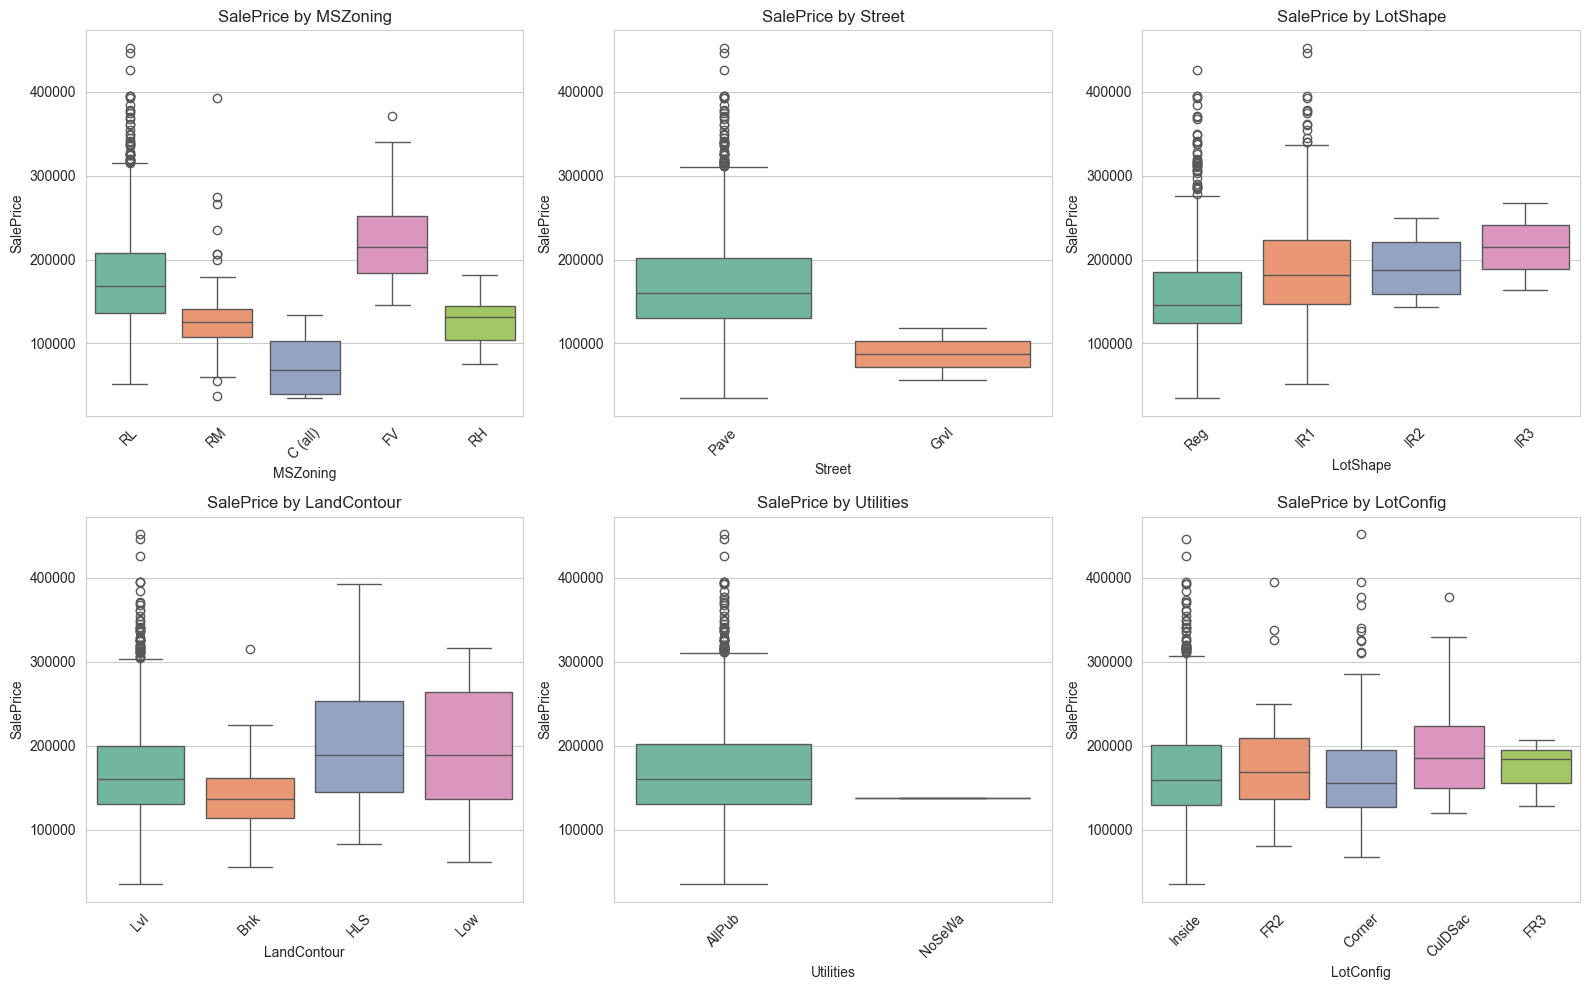

In [166]:
moderate_cardinality_features = [col for col in categorical_features if (10 >= df_original[col].nunique() >= 2)][:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, feature in enumerate(moderate_cardinality_features):
    sns.boxplot(x=df_original[feature], y=df_original['SalePrice'], ax=axes[i // 3, i % 3], color='lightcoral', palette='Set2')
    axes[i // 3, i % 3].set_title(f'SalePrice by {feature}')
    axes[i // 3, i % 3].set_xlabel(feature)
    axes[i // 3, i % 3].set_ylabel('SalePrice')
    axes[i // 3, i % 3].tick_params(axis='x', rotation=45)
for j in range(i + 1, 6):
    axes[j // 3, j % 3].axis('off')
plt.tight_layout()
plt.show()

### Step 6.1: Statistical Analysis by Category

In [167]:
df_original[moderate_cardinality_features].nunique().sort_values(ascending=False)
moderate_card_list = df_original[moderate_cardinality_features].nunique().sort_values(ascending=False).index[:3].tolist()
moderate_card_list[2] = 'LotShape'
for feature in moderate_card_list:
    stats_table = df_original.groupby(feature)['SalePrice'].agg(['count', 'mean', 'median', 'std']).sort_values(by='mean', ascending=False)
    print(f"\nStatistics for SalePrice by {feature}:")
    print(stats_table)


Statistics for SalePrice by MSZoning:
          count           mean    median           std
MSZoning                                              
FV           55  223685.981818  215200.0  51021.978085
RL          935  179287.025668  168500.0  61386.401439
RM          171  126515.608187  125000.0  38620.492417
RH           14  125781.000000  131500.0  32612.091790
C (all)       9   73808.888889   68400.0  35759.614502

Statistics for SalePrice by LotConfig:
           count           mean    median           std
LotConfig                                              
CulDSac       64  194190.593750  185750.0  54745.210259
FR2           38  180661.184211  169250.0  67337.957293
FR3            3  172966.666667  183900.0  40619.002121
Inside       875  171191.858286  159000.0  62378.467826
Corner       204  168580.303922  155000.0  63042.541633

Statistics for SalePrice by LotShape:
          count           mean    median           std
LotShape                                          

---
## Step 7: Multivariate Analysis

Examine relationships between multiple features simultaneously.

### Step 7.1: Correlation Heatmap

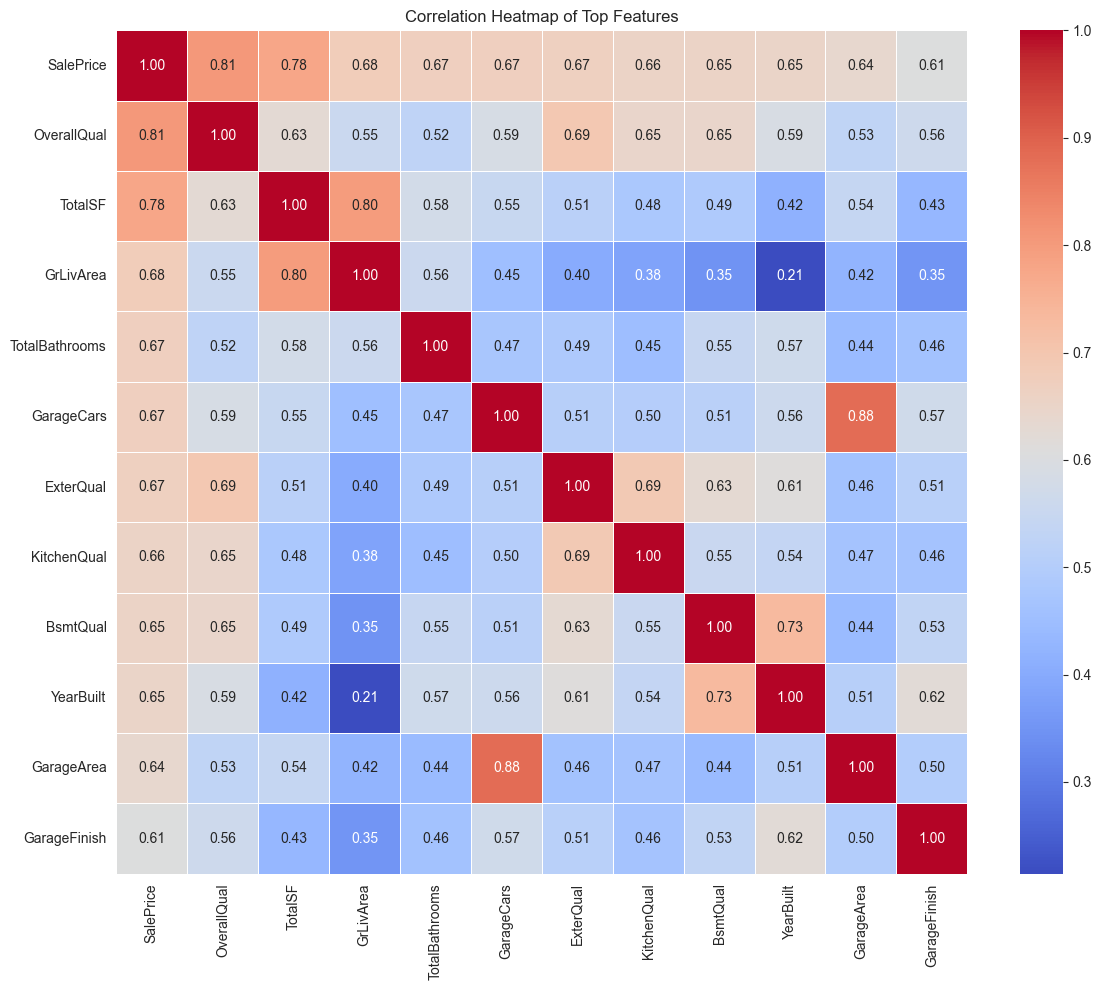

In [168]:
top_corr_features = saleprice_correlations.head(12).index.tolist()
corr_matrix = df_fe[top_corr_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Top Features')
plt.tight_layout()
plt.show()



### Step 7.2: Pair Plot of Key Features

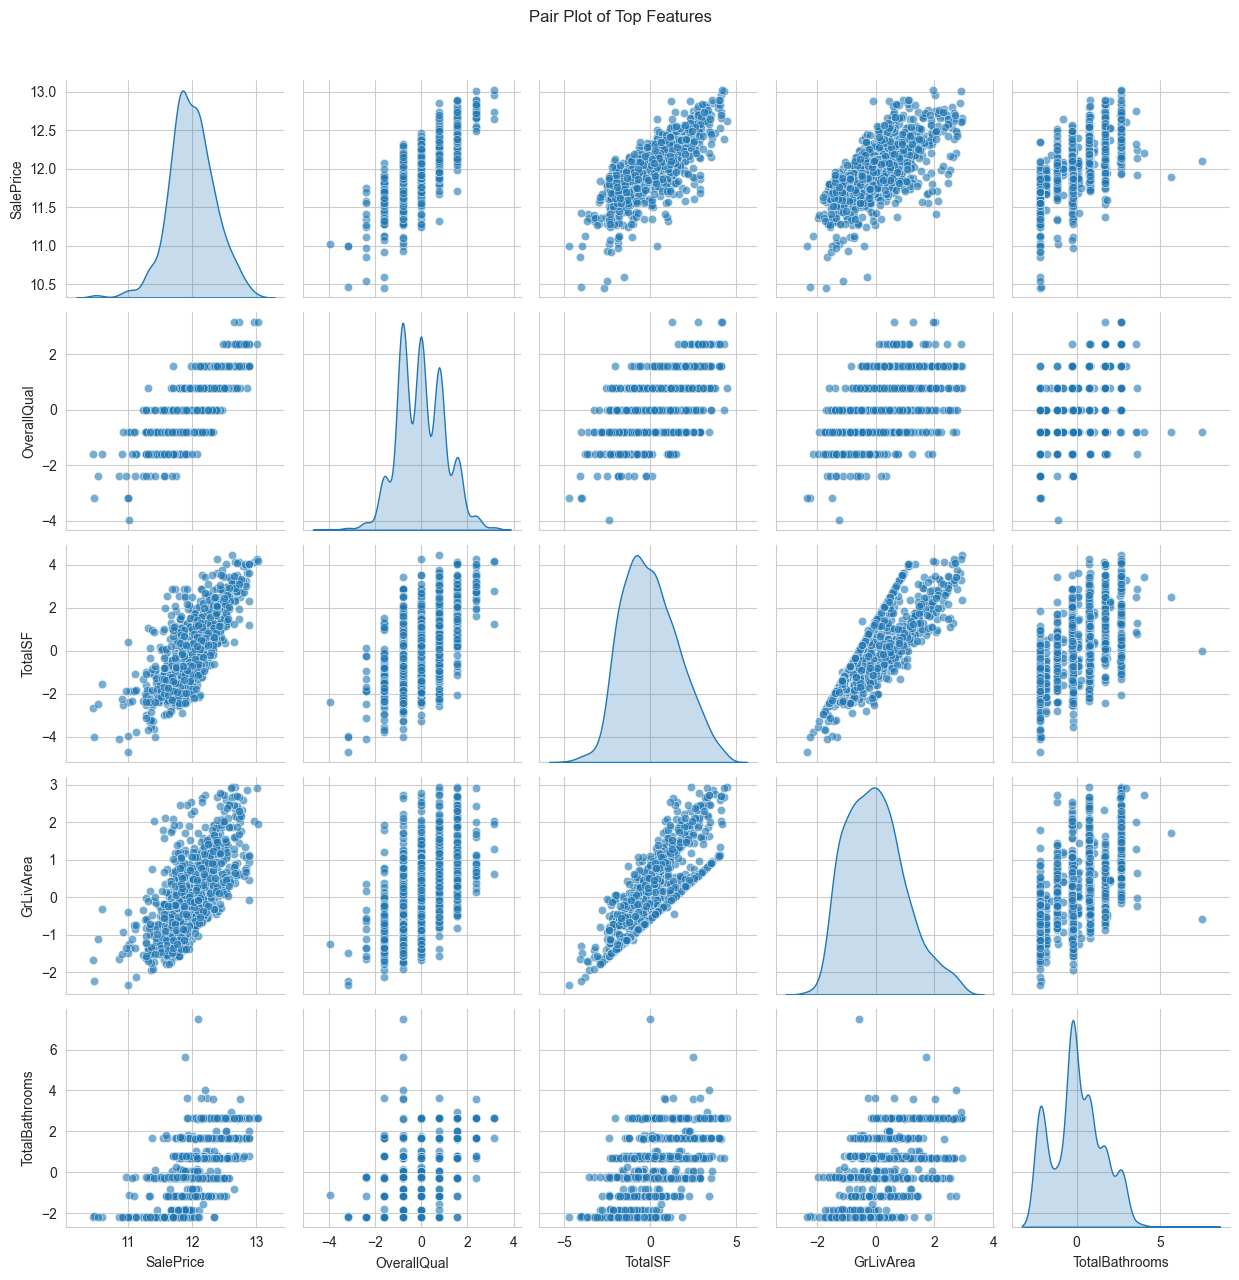

In [169]:

feature_cols = saleprice_correlations.head(5).index.tolist()
pairplot_df = df_fe[feature_cols]
sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Top Features', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 8: Analyze Engineered Features

Engineered feature review from Phase 3.

In [170]:
try:
    with open("new_features_list.txt",'r') as file:
        new_features = file.readlines()
        new_features = [feature.strip() for feature in new_features][2:] # Remove newline characters
        for i in range(len(new_features)):
            new_features[i] = new_features[i][3:].strip() # Extract feature name before colon
        print("Newly Created Features:")
        for feature in new_features:
            print(feature)
except FileNotFoundError:
    print("No new features file found. This file is created in Phase 3.") 

No new features file found. This file is created in Phase 3.


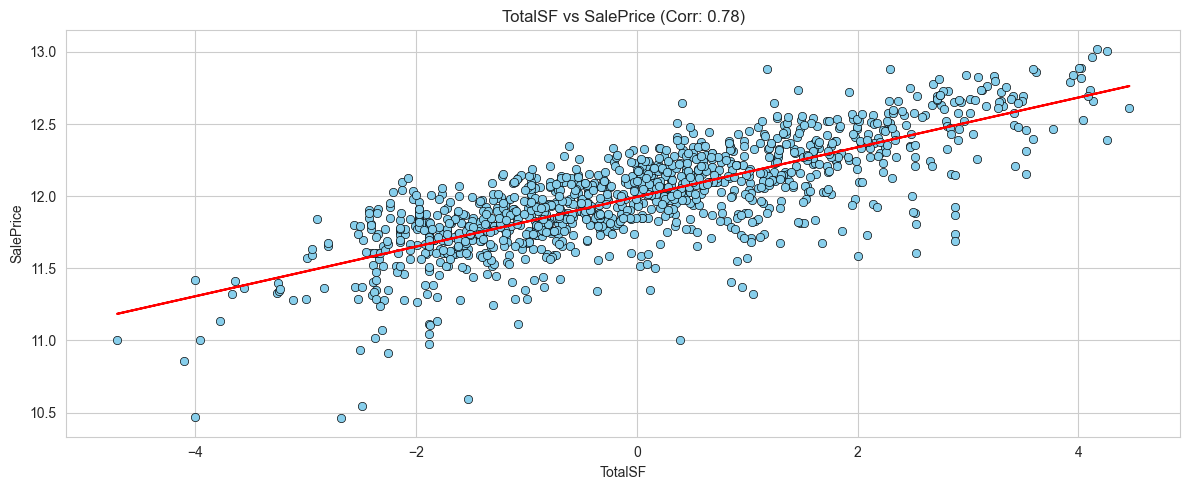

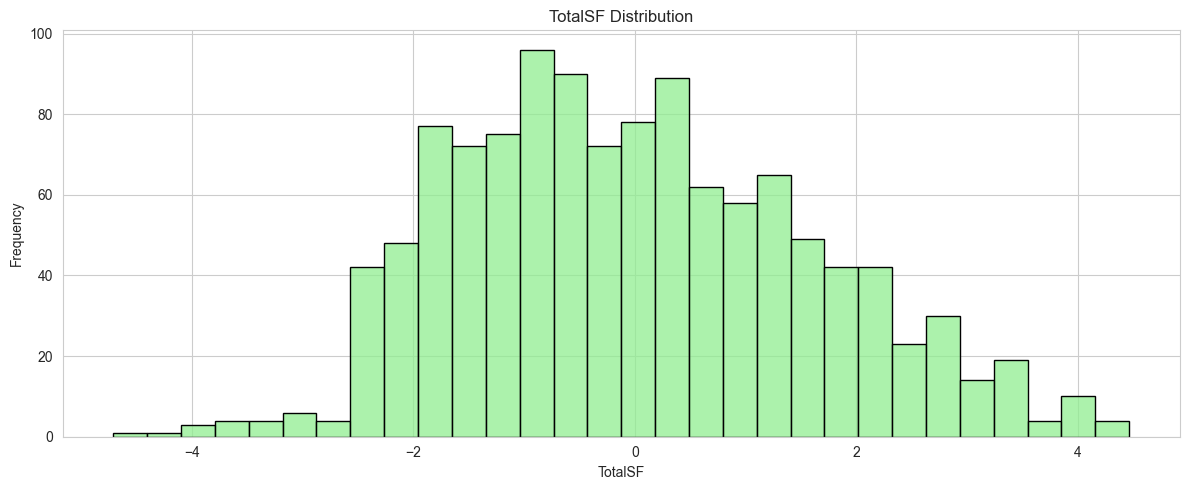

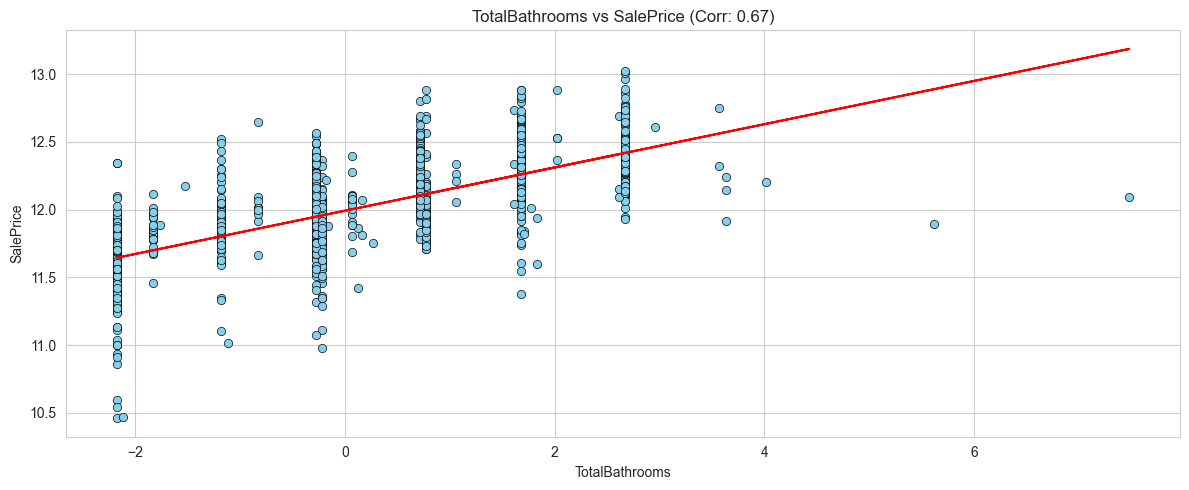

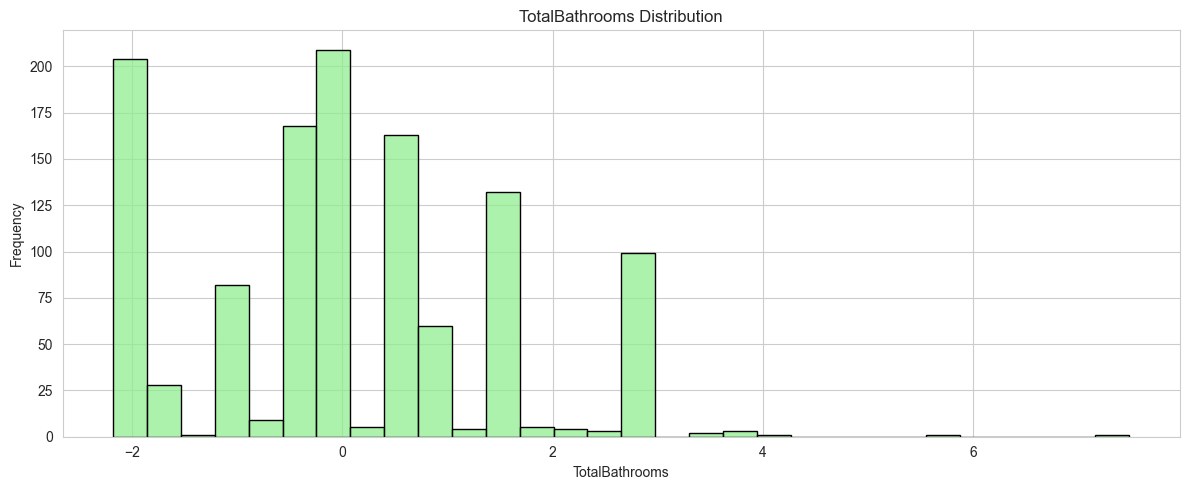

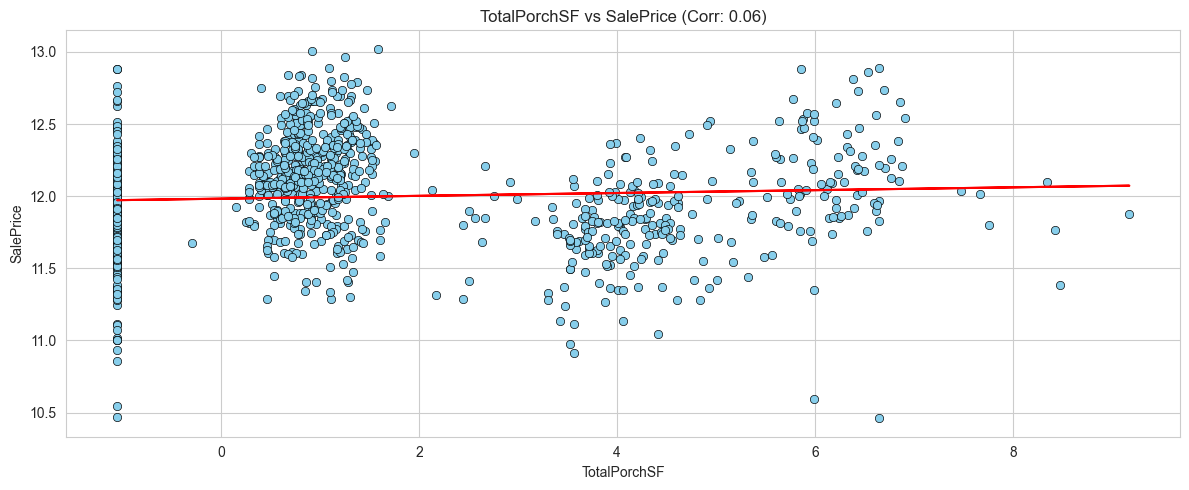

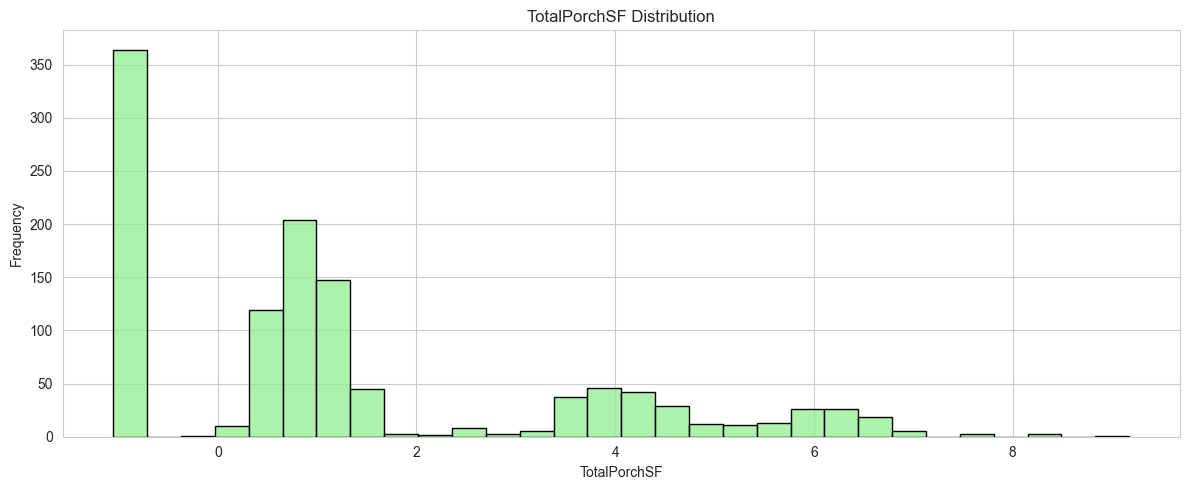

GarageArea_to_LivingArea not found in the dataset. Please check the feature name and ensure it was created in Phase 3.
Porch_to_LivingArea not found in the dataset. Please check the feature name and ensure it was created in Phase 3.
Bedrooms_to_LivingArea not found in the dataset. Please check the feature name and ensure it was created in Phase 3.


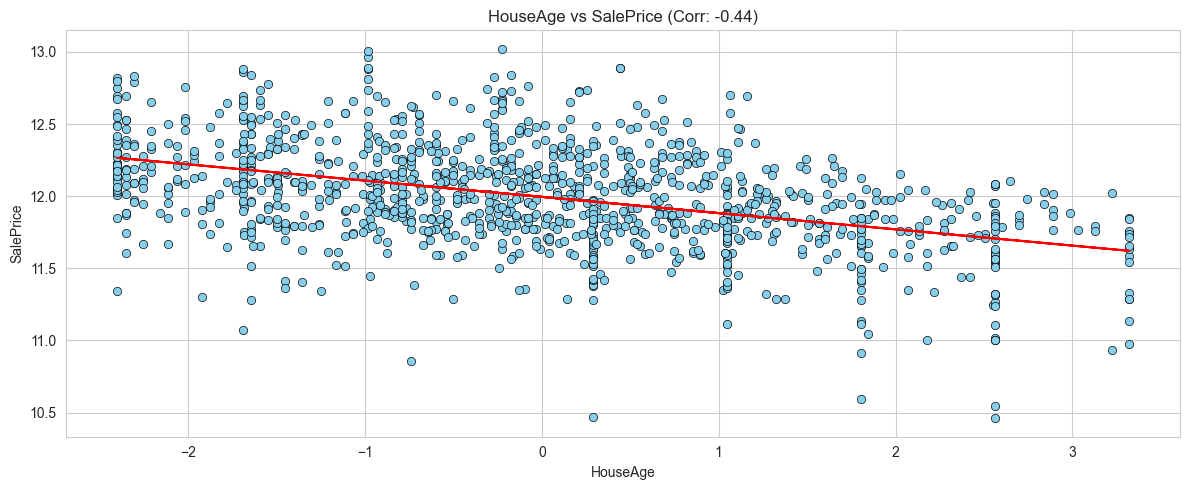

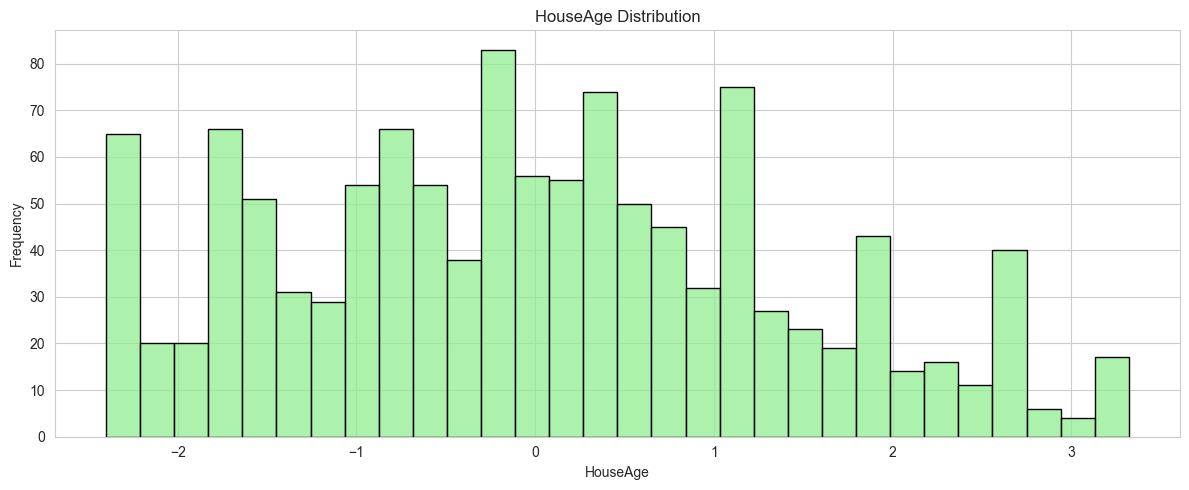

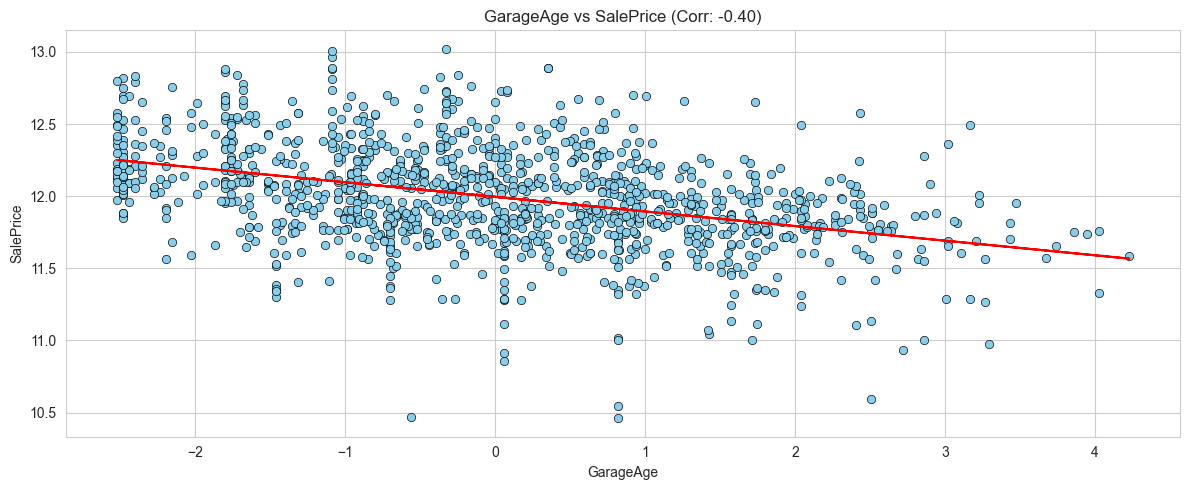

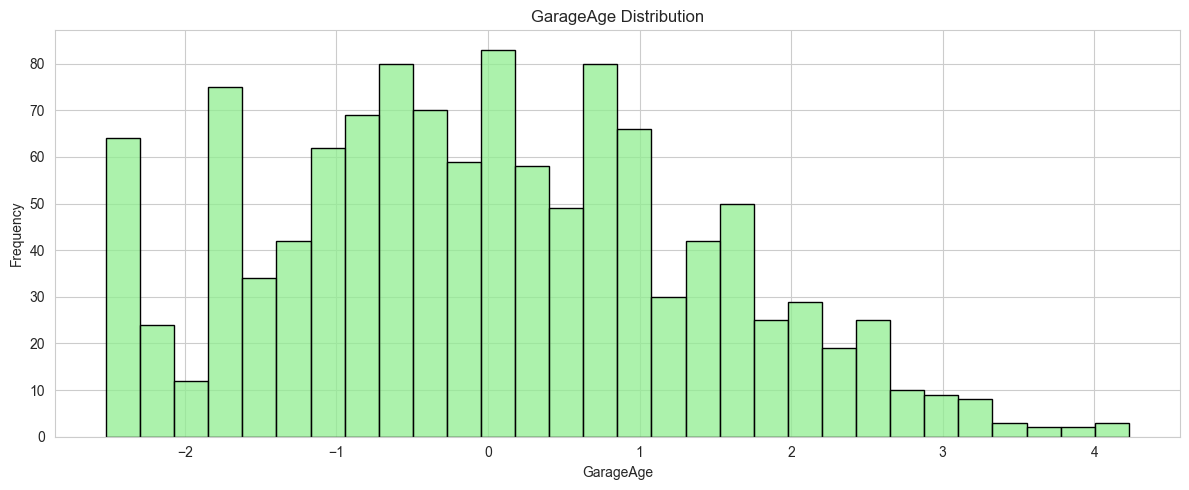

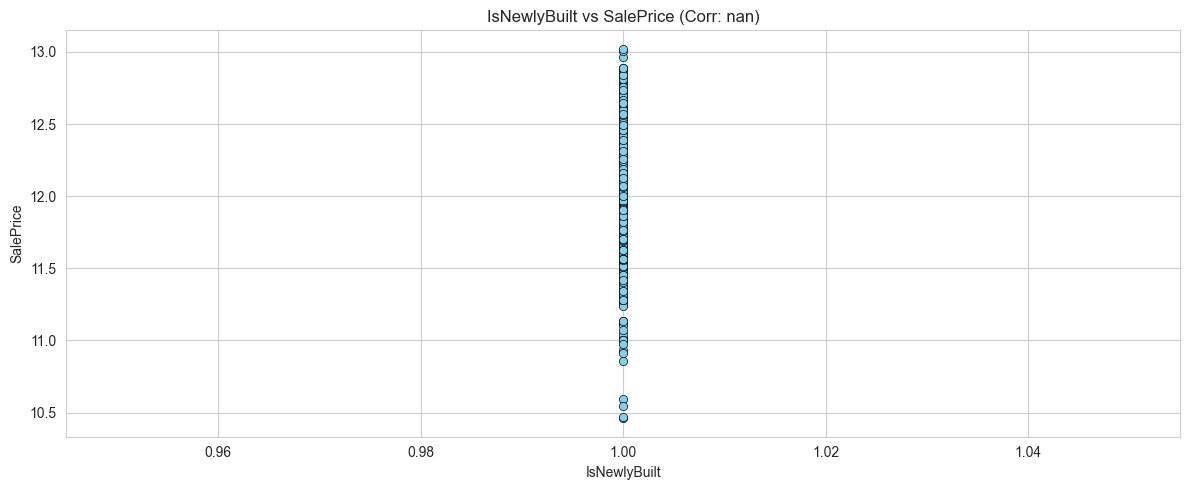

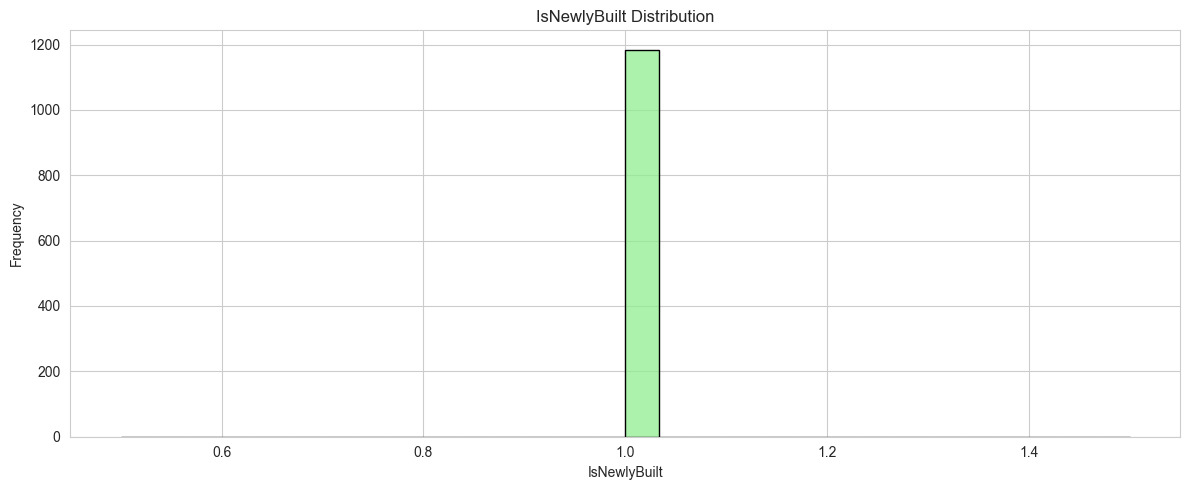

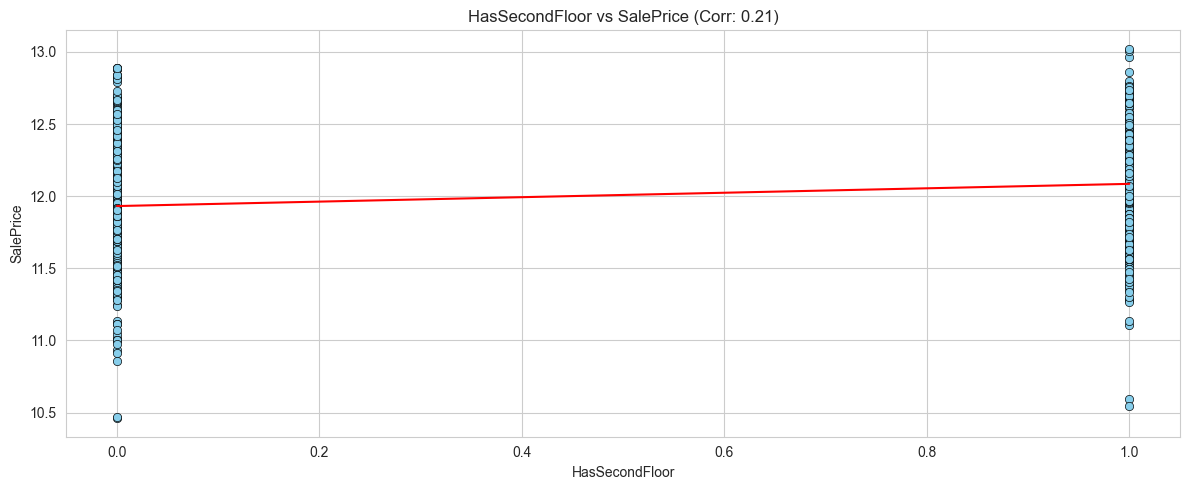

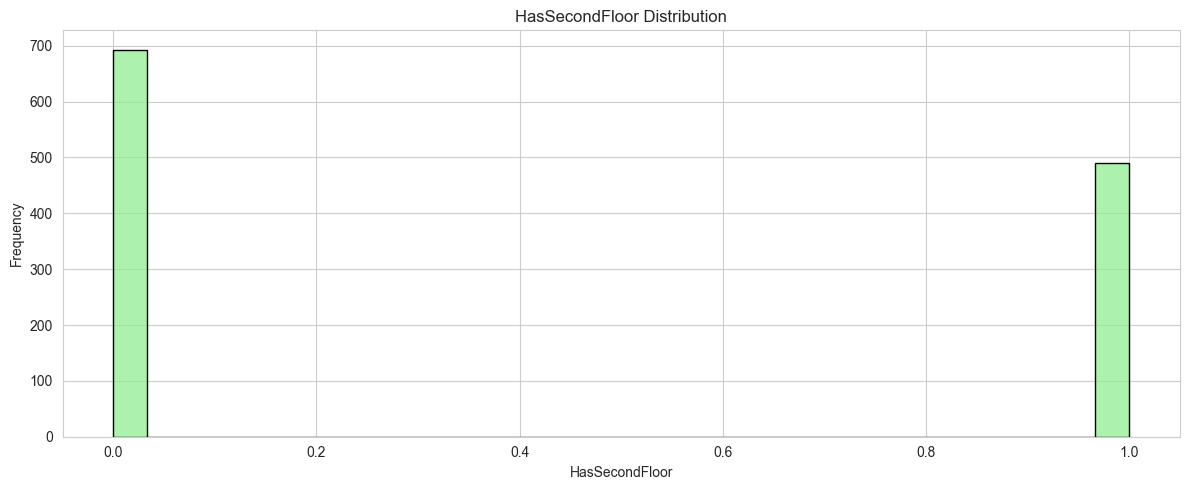

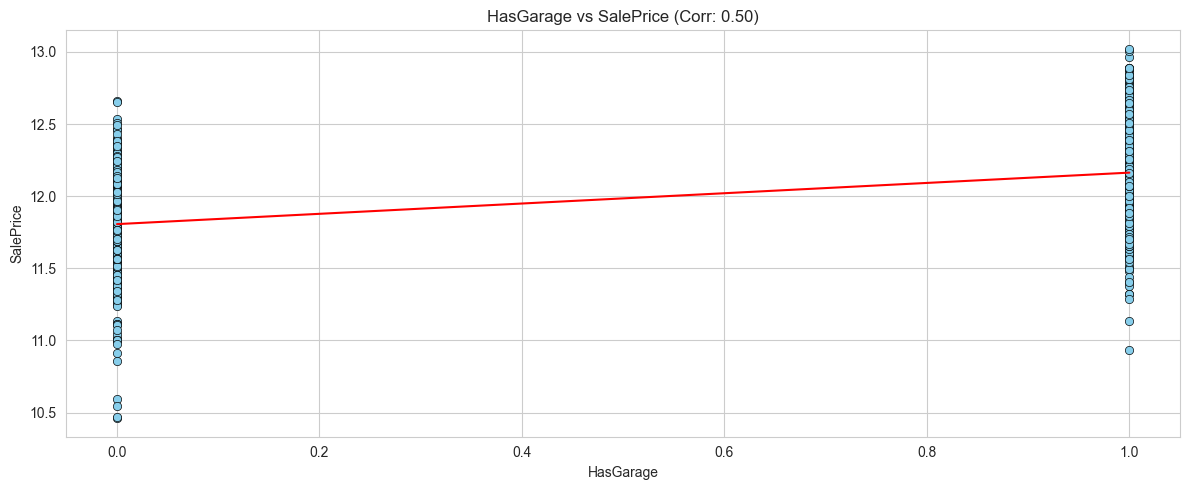

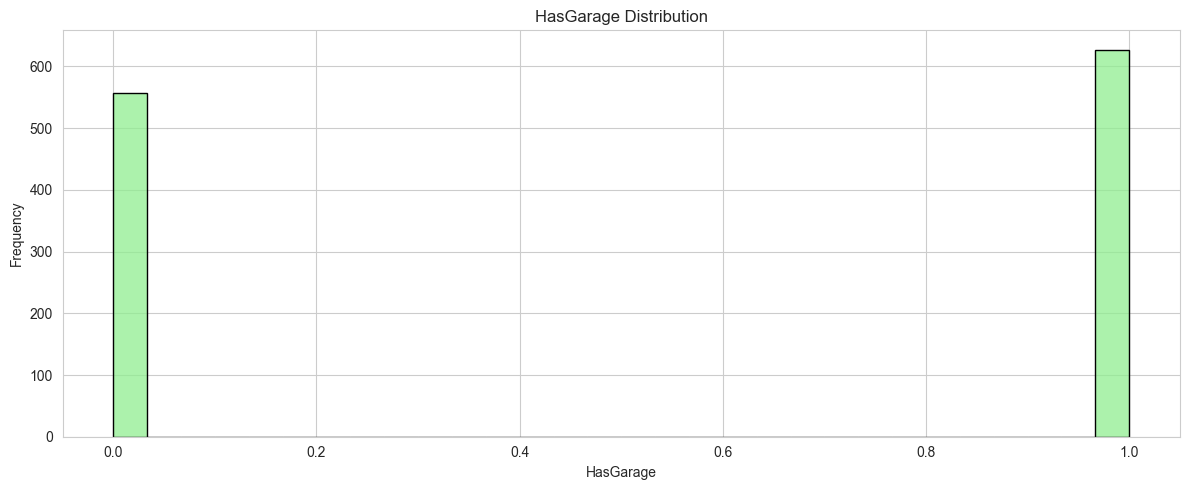

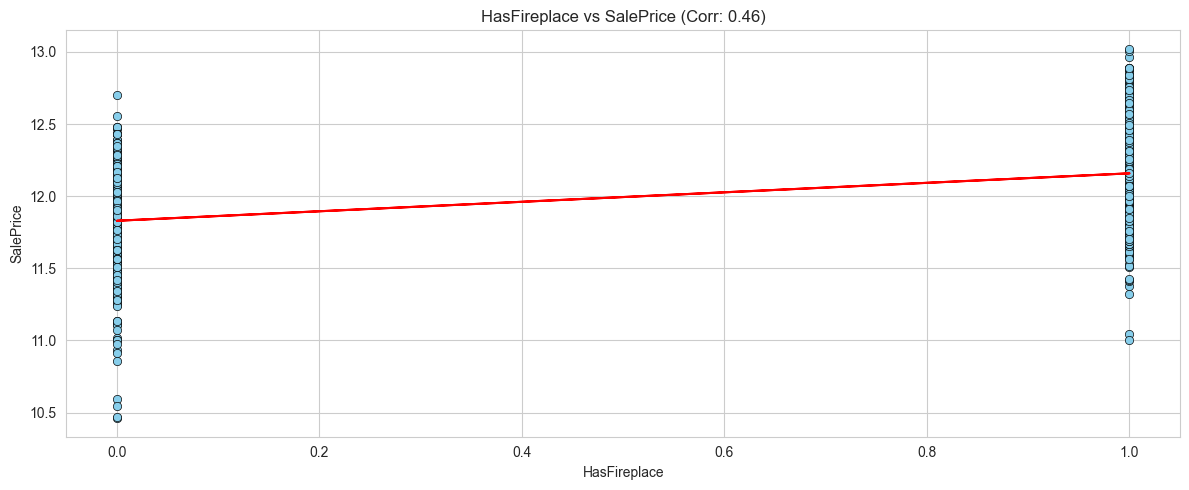

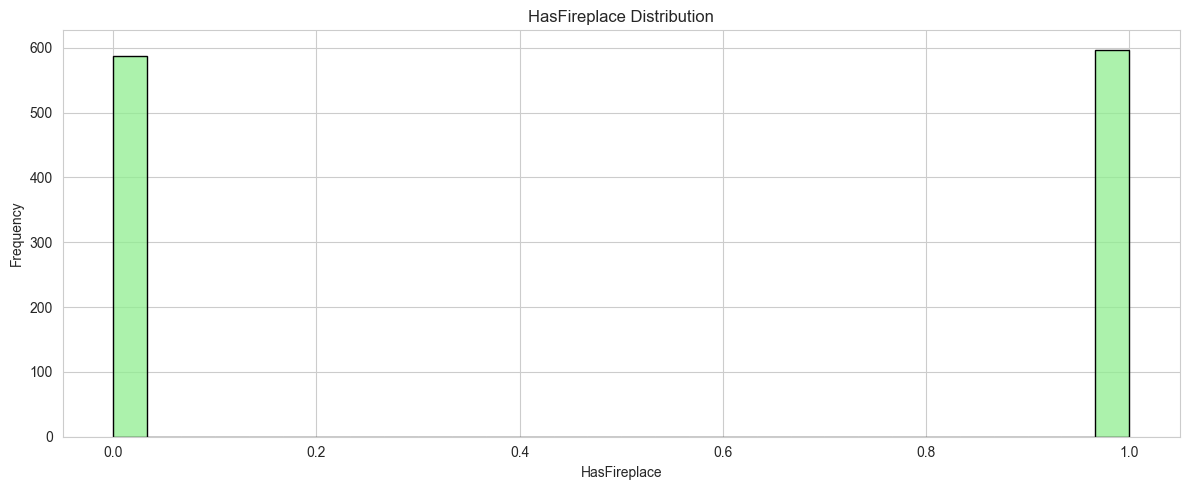

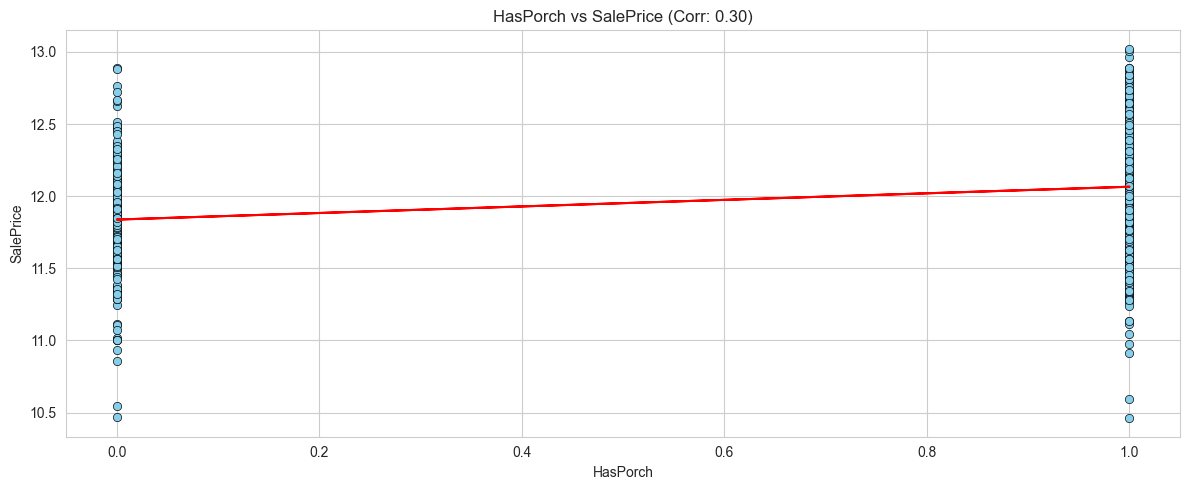

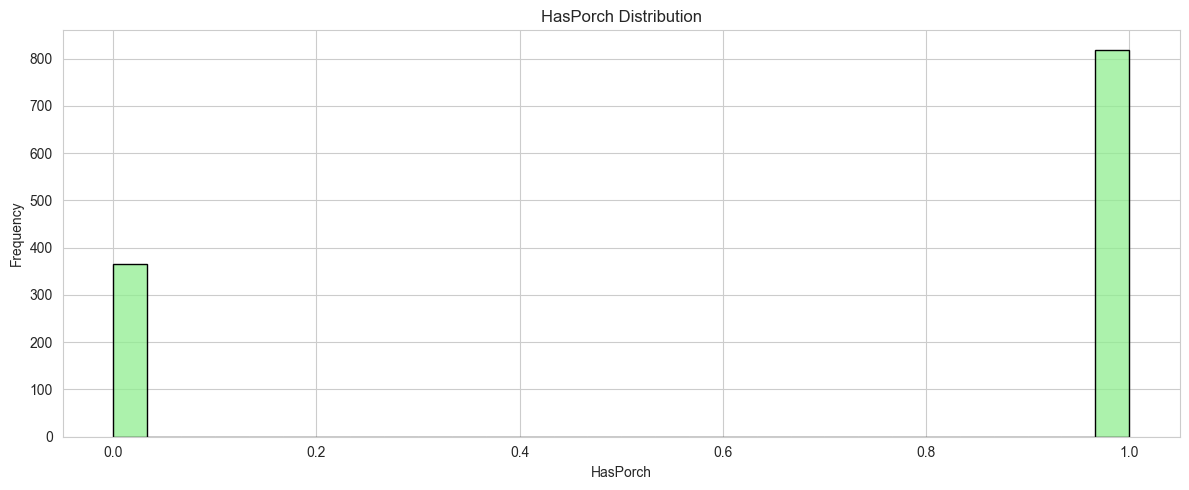

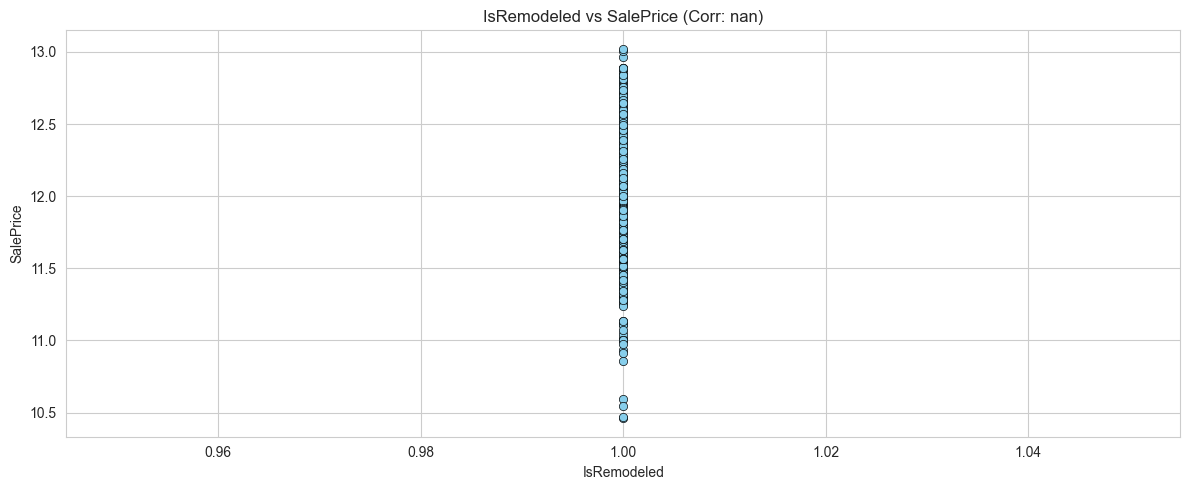

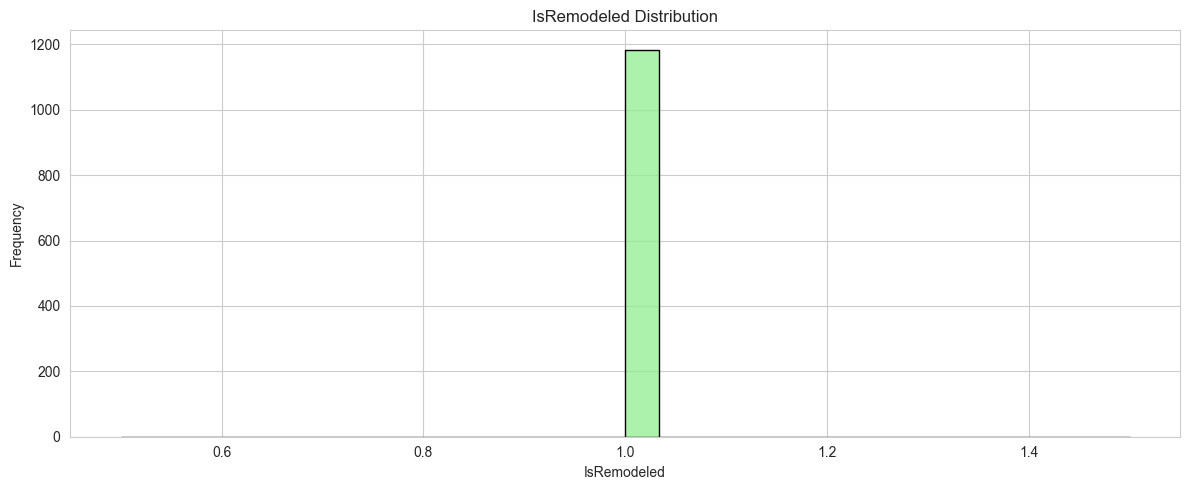

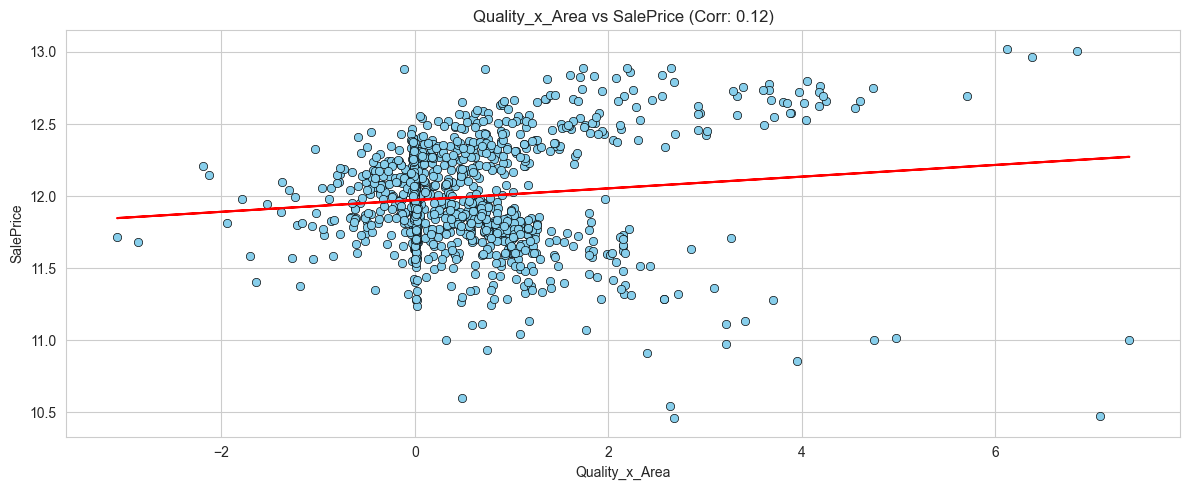

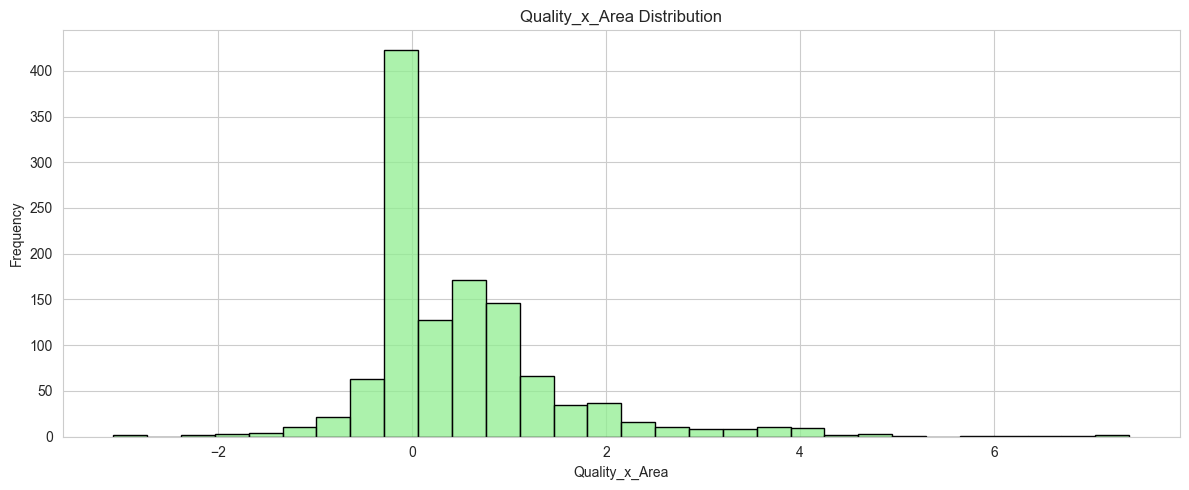

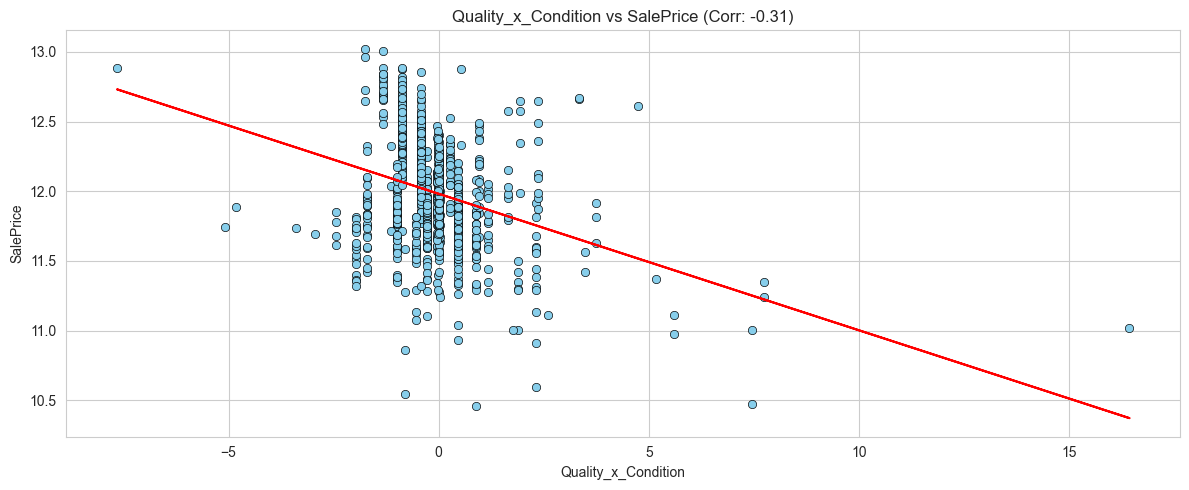

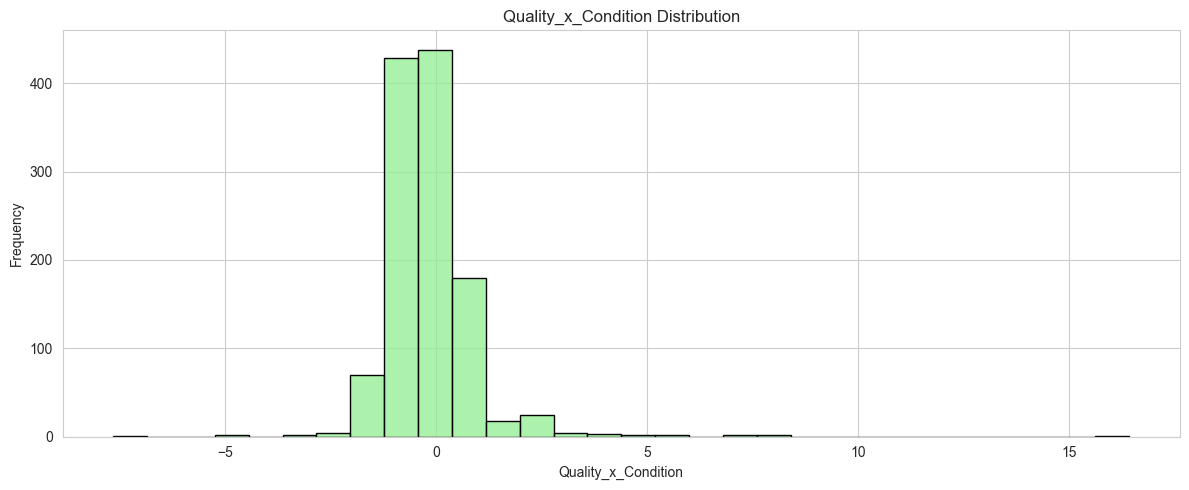

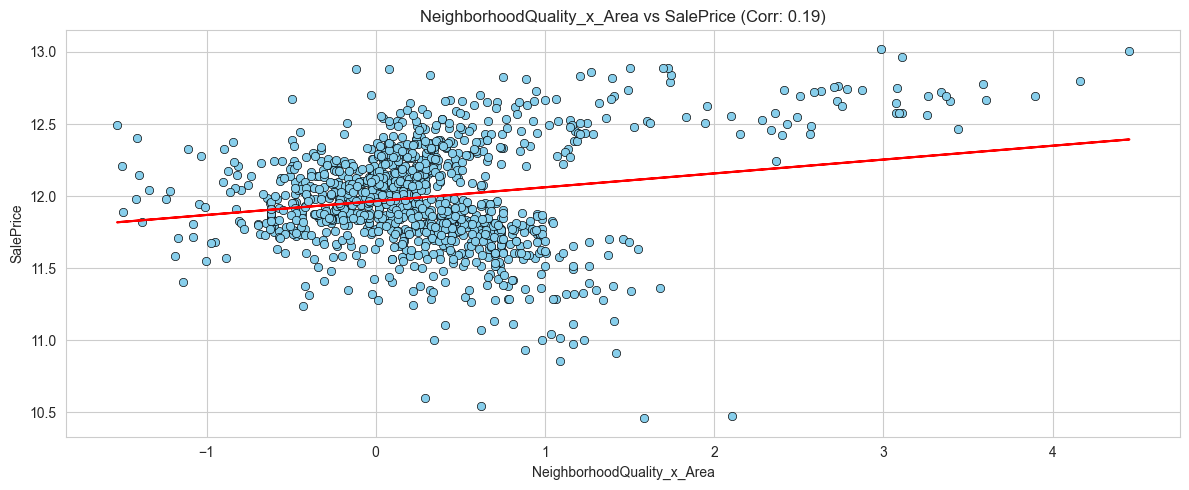

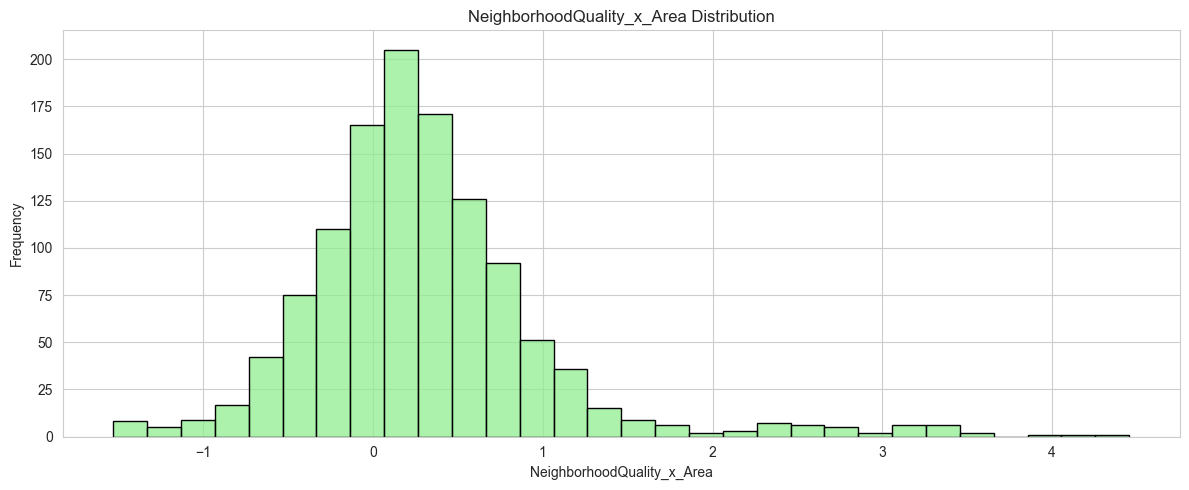

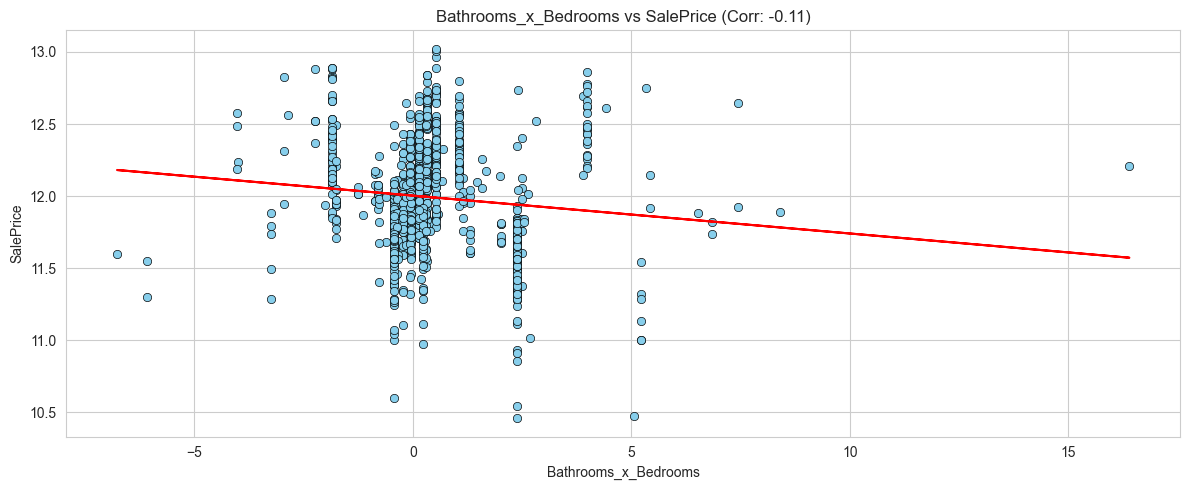

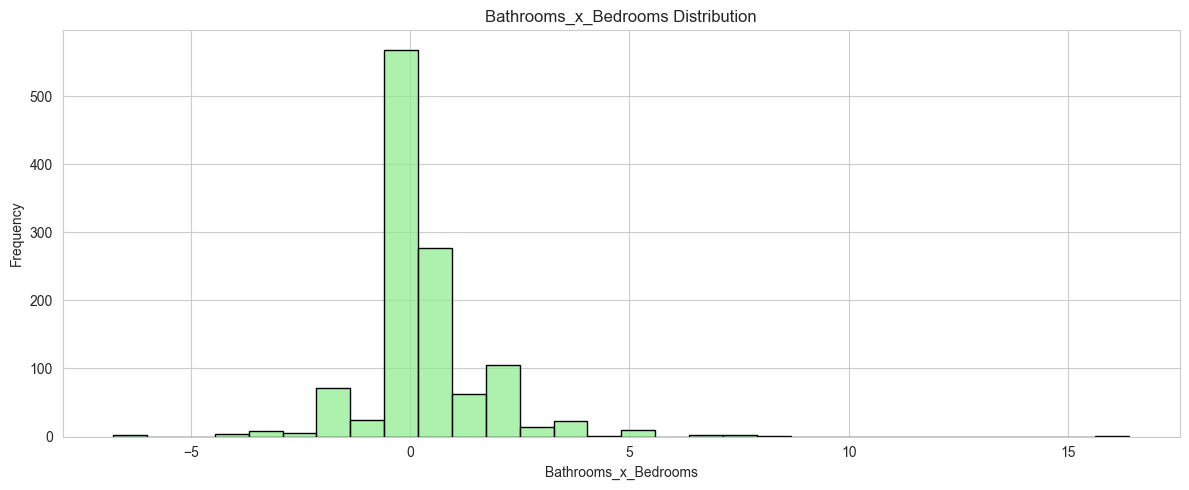

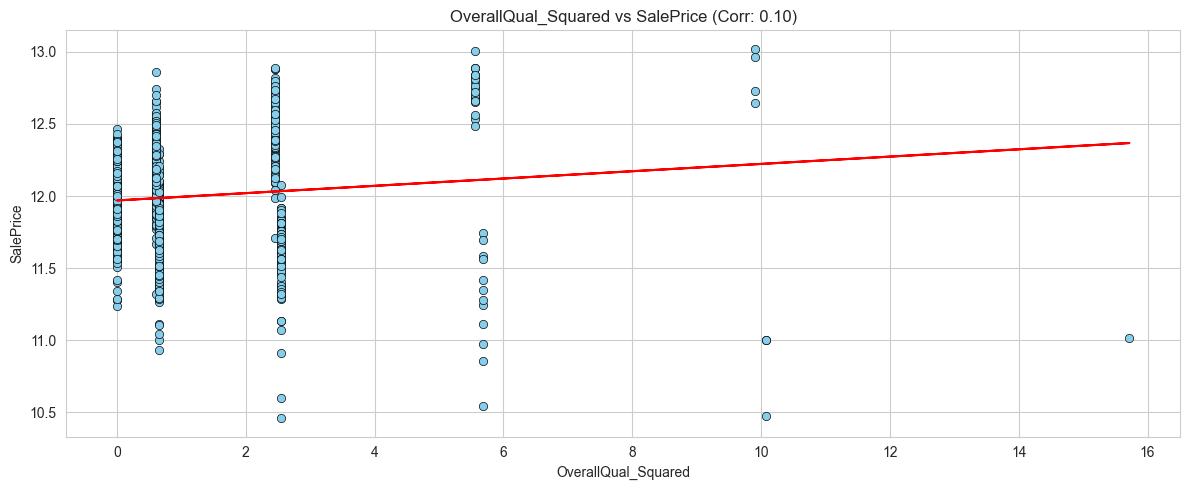

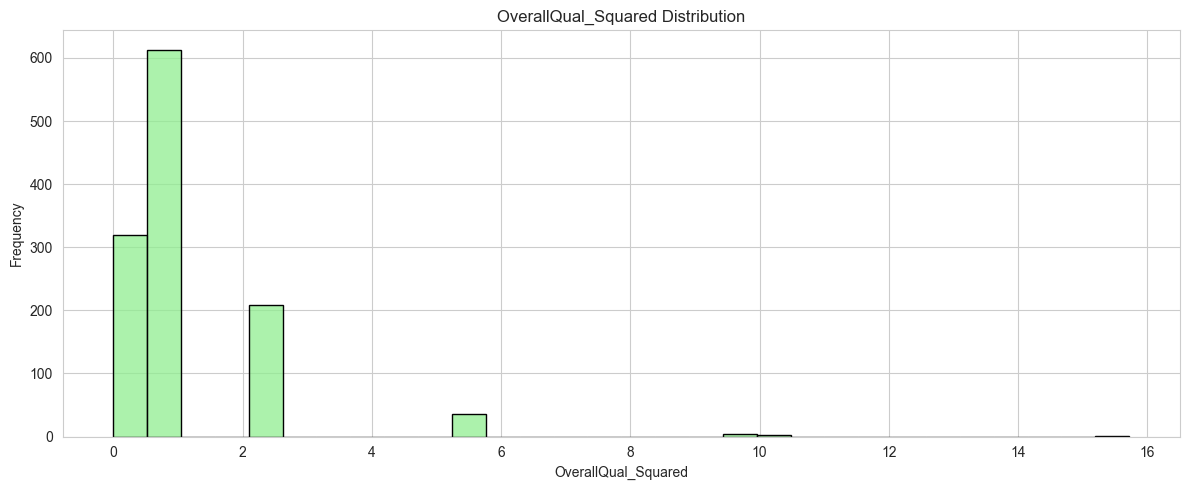

In [171]:
for feature in new_features:
    if feature in df_fe.columns:
        plt.figure(figsize=(12, 5))
        sns.scatterplot(x=df_fe[feature], y=df_fe['SalePrice'], color='skyblue', edgecolor='black')
        z = np.polyfit(df_fe[feature], df_fe['SalePrice'], 1)
        p = np.poly1d(z)
        plt.plot(df_fe[feature], p(df_fe[feature]), color='red')
        plt.title(f'{feature} vs SalePrice (Corr: {df_fe[[feature, "SalePrice"]].corr().iloc[0, 1]:.2f})')
        plt.xlabel(feature)
        plt.ylabel('SalePrice')
        plt.tight_layout()
        plt.show()
        
        plt.figure(figsize=(12, 5))
        sns.histplot(df_fe[feature], bins=30, color='lightgreen', edgecolor='black')
        plt.title(f'{feature} Distribution')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    else:
        print(f"{feature} not found in the dataset. Please check the feature name and ensure it was created in Phase 3.")


---
## Step 9: Key Insights and Patterns

Key EDA findings summary.

### Step 9.1: Document Your Findings

Notes from the analysis:

#### 1. Target Variable (SalePrice)
- What is the typical price range?
    - 35311$ to 426000$ 
- Is the distribution normal or skewed?
    - It is right-skewed.
- Are there significant outliers?
    - There are some outliers higher than upper bound
#### 2. Most Important Features
- Which 5 features have the strongest correlation with SalePrice?
    - Quality_x_Area, OverallQual_Squared, NeighborhoodQuality_x_Area, OverallQual, TotalSF 
- Are the relationships linear or non-linear?
    - We can consider them linear although there is some spread for datas but mostly they are linear. 

#### 3. Categorical Insights
- Which categorical features show the biggest price differences?
- Are there any surprising patterns?

#### 4. Feature Relationships
- Which features are highly correlated with each other?
    -   OverallQual_Squared vs OverallQual
        Quality_x_Area vs NeighborhoodQuality_x_Area
        NeighborhoodQuality_x_Area vs GrLivArea
        Quality_x_Area vs GrLivArea
        GarageCars vs GarageArea
        TotalSF vs GrLivArea
        NeighborhoodQuality_x_Area vs TotalSF
        Quality_x_Area vs TotalSF
        Quality_x_Area vs OverallQual_Squared
        SalePrice vs Quality_x_Area
        Quality_x_Area vs OverallQual
        SalePrice vs OverallQual_Squared
        SalePrice vs NeighborhoodQuality_x_Area
        SalePrice vs OverallQual
        SalePrice vs TotalSF
        OverallQual_Squared vs NeighborhoodQuality_x_Area
        NeighborhoodQuality_x_Area vs OverallQual
- Does this suggest multicollinearity concerns?
    - Actually yes, because we should consider these relationships while creating our regression model too.

#### 5. Engineered Features
- Did your engineered features improve correlation with target?
    - Yes, we can see the improvements basing on the correlation heatmap.
- Which engineered features are most promising?
    - Quality_x_Area, OverallQual_Squared, NeighborhoodQuality_x_Area, OverallQual, TotalSF

**Write your insights here:**

In [172]:
print("DATASET OVERVIEW")
print(f"Total samples: {df_fe.shape[0]}")
print(f"Total features: {df_fe.shape[1]}")
print(f"Numerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print("\nTARGET VARIABLE (SalePrice)")
print(f"Mean: ${saleprice_stats['Mean']:,.2f}")
print(f"Median: ${saleprice_stats['Median']:,.2f}")
print(f"Range: ${saleprice_stats['Range']:,.2f}")
print(f"Skewness: {saleprice_stats['Skewness']:.2f}")
print("\nTOP 5 MOST CORRELATED FEATURES WITH SalePrice:")
print(saleprice_correlations.head(5))
print("\nKEY OBSERVATIONS:")
print("- SalePrice is right-skewed, indicating a long tail of expensive houses.")
print("- GrLivArea, TotalBsmtSF, and GarageArea are among the top features most correlated with SalePrice.")
print("- Categorical features like Neighborhood and OverallQual show significant differences in SalePrice across categories.")
print("\nRECOMMENDATIONS FOR MODELING:")
print("- Consider log-transforming SalePrice to reduce skewness.")
print("- Focus on top correlated features for feature selection.")


DATASET OVERVIEW
Total samples: 1184
Total features: 157
Numerical features: 71
Categorical features: 37

TARGET VARIABLE (SalePrice)
Mean: $172,293.48
Median: $159,697.50
Range: $417,050.00
Skewness: 1.11

TOP 5 MOST CORRELATED FEATURES WITH SalePrice:
SalePrice         1.000000
OverallQual       0.805782
TotalSF           0.777557
GrLivArea         0.678242
TotalBathrooms    0.671448
Name: SalePrice, dtype: float64

KEY OBSERVATIONS:
- SalePrice is right-skewed, indicating a long tail of expensive houses.
- GrLivArea, TotalBsmtSF, and GarageArea are among the top features most correlated with SalePrice.
- Categorical features like Neighborhood and OverallQual show significant differences in SalePrice across categories.

RECOMMENDATIONS FOR MODELING:
- Consider log-transforming SalePrice to reduce skewness.
- Focus on top correlated features for feature selection.


---
## Step 10: Final Visualizations

Final visualizations that tell the story of house prices.

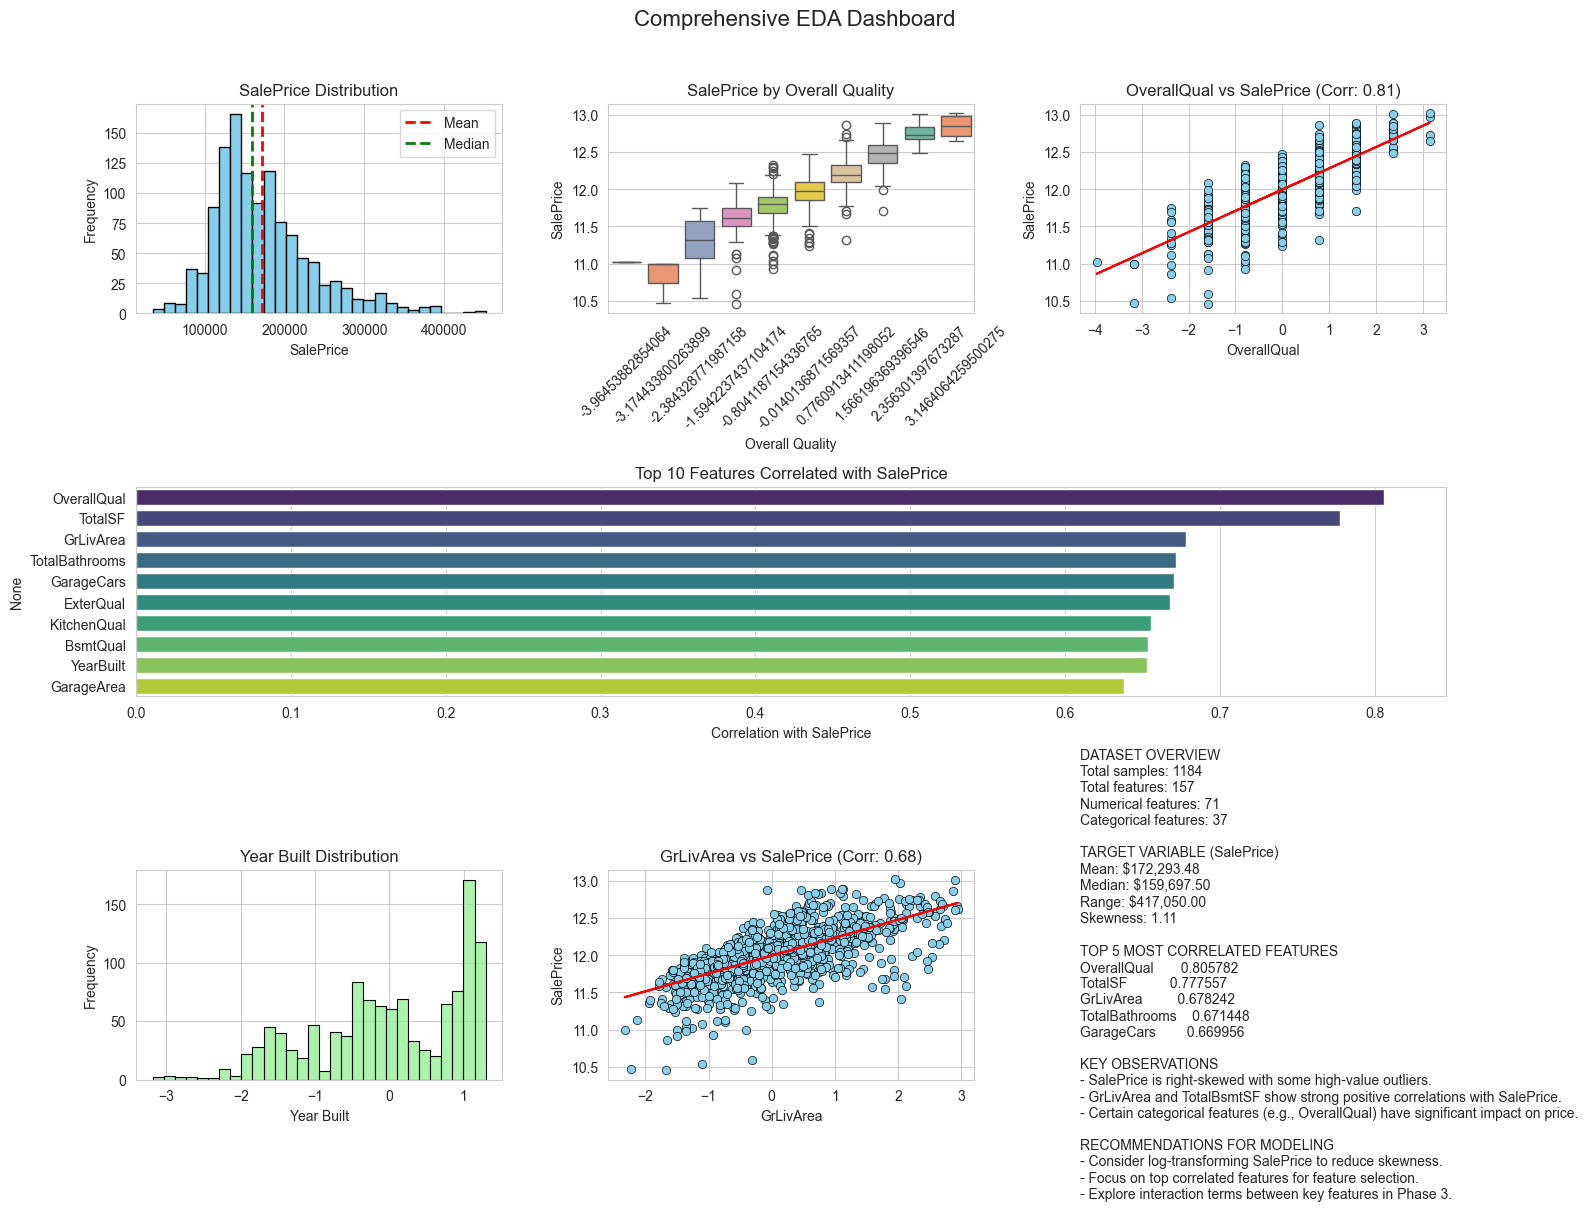

In [173]:

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3)
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(y['SalePrice'], bins=30, color='skyblue', edgecolor='black')
ax1.axvline(y['SalePrice'].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
ax1.axvline(y['SalePrice'].median(), color='green', linestyle='dashed', linewidth=2, label='Median')
ax1.set_title('SalePrice Distribution')
ax1.set_xlabel('SalePrice')
ax1.set_ylabel('Frequency')
ax1.legend()
if 'OverallQual' in df_fe.columns:
    ax2 = fig.add_subplot(gs[0, 1])
    sns.boxplot(x=df_fe['OverallQual'], y=df_fe['SalePrice'], ax=ax2, color='lightcoral', palette='Set2')
    ax2.set_title('SalePrice by Overall Quality')
    ax2.set_xlabel('Overall Quality')
    ax2.set_ylabel('SalePrice')
    ax2.tick_params(axis='x', rotation=45)
top_feature = saleprice_correlations.drop('SalePrice').idxmax()
ax3 = fig.add_subplot(gs[0, 2])
sns.scatterplot(x=df_fe[top_feature], y=df_fe['SalePrice'], ax=ax3, color='skyblue', edgecolor='black')
z = np.polyfit(df_fe[top_feature], df_fe['SalePrice'], 1)
p = np.poly1d(z)
ax3.plot(df_fe[top_feature], p(df_fe[top_feature]), color='red')
ax3.set_title(f'{top_feature} vs SalePrice (Corr: {saleprice_correlations[top_feature]:.2f})')
ax3.set_xlabel(top_feature)
ax3.set_ylabel('SalePrice')
ax4 = fig.add_subplot(gs[1, :])
top_corr_features = saleprice_correlations.drop('SalePrice').head(10)
sns.barplot(x=top_corr_features.values, y=top_corr_features.index, palette='viridis', ax=ax4)
ax4.set_xlabel('Correlation with SalePrice')
ax4.set_title('Top 10 Features Correlated with SalePrice')
ax4.axvline(0, color='black', linestyle='--')
if 'YearBuilt' in df_fe.columns:
    ax5 = fig.add_subplot(gs[2, 0])
    sns.histplot(df_fe['YearBuilt'], bins=30, color='lightgreen', edgecolor='black', ax=ax5)
    ax5.set_title('Year Built Distribution')
    ax5.set_xlabel('Year Built')
    ax5.set_ylabel('Frequency')
if 'GrLivArea' in df_fe.columns:
    ax6 = fig.add_subplot(gs[2, 1])
    sns.scatterplot(x=df_fe['GrLivArea'], y=df_fe['SalePrice'], ax=ax6, color='skyblue', edgecolor='black')
    z = np.polyfit(df_fe['GrLivArea'], df_fe['SalePrice'], 1)
    p = np.poly1d(z)
    ax6.plot(df_fe['GrLivArea'], p(df_fe['GrLivArea']), color='red')
    ax6.set_title(f'GrLivArea vs SalePrice (Corr: {saleprice_correlations["GrLivArea"]:.2f})')
    ax6.set_xlabel('GrLivArea')
    ax6.set_ylabel('SalePrice')
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
summary_text = (f"DATASET OVERVIEW\n"
f"Total samples: {df_fe.shape[0]}\n"
f"Total features: {df_fe.shape[1]}\n"
f"Numerical features: {len(numerical_features)}\n"
f"Categorical features: {len(categorical_features)}\n\n"
f"TARGET VARIABLE (SalePrice)\n"
f"Mean: ${saleprice_stats['Mean']:,.2f}\n"
f"Median: ${saleprice_stats['Median']:,.2f}\n"
f"Range: ${saleprice_stats['Range']:,.2f}\n"
f"Skewness: {saleprice_stats['Skewness']:.2f}\n\n"
f"TOP 5 MOST CORRELATED FEATURES\n"
f"{top_corr_features.head(5).to_string()}\n\n"
f"KEY OBSERVATIONS\n"
f"- SalePrice is right-skewed with some high-value outliers.\n"
f"- GrLivArea and TotalBsmtSF show strong positive correlations with SalePrice.\n"
f"- Certain categorical features (e.g., OverallQual) have significant impact on price.\n\n"
f"RECOMMENDATIONS FOR MODELING\n"
f"- Consider log-transforming SalePrice to reduce skewness.\n"
f"- Focus on top correlated features for feature selection.\n"
f"- Explore interaction terms between key features in Phase 3.")
ax7.text(0, 0.5, summary_text, fontsize=10, va='center')
plt.suptitle('Comprehensive EDA Dashboard', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## Summary and Final Reflection

### Summary Highlights:

1. Conducted comprehensive analysis of the target variable
2. Performed univariate analysis on numerical and categorical features
3. Executed bivariate analysis to understand feature-target relationships
4. Conducted multivariate analysis using correlation matrices and pair plots
5. Evaluated engineered features from Phase 3
6. Identified key patterns and insights in the data
7. Created professional visualizations
8. Documented findings and recommendations

### Key Takeaways:

EDA is an iterative process that helps:
- Understand data deeply
- Identify potential issues before modeling
- Generate hypotheses about relationships
- Make informed decisions about feature selection and engineering
- Communicate insights to stakeholders

### Reflection Notes:

- Top 3 factors affecting house prices in this dataset
- Unexpected patterns or relationships
- Features to exclude from modeling and why
- Transformations most important for modeling success
- Modeling approaches that seem most appropriate
- Additional features that might improve predictions

### Linear Regression Phase Overview:

Phase 5 focuses on:
1. Building baseline models with the cleaned and preprocessed data
2. Training regression models to predict house prices
3. Evaluating model performance with appropriate metrics
4. Iterating on feature engineering based on results
5. Creating predictions for the test dataset
6. Preparing submissions for Kaggle

### Workflow Status:

Completed data preparation stages:
- Data Cleaning
- Data Preprocessing
- Feature Engineering
- Exploratory Data Analysis

Dataset is ready for modeling.